<a href="https://colab.research.google.com/github/kauefs/ML/blob/%40/notebooks/AKL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<center>

![2024.10.28  ](https://img.shields.io/badge/2024.10.28-000000)

[![ƊⱭȾɅViƧi🧿Ƞ](https://img.shields.io/badge/ƊⱭȾɅViƧi🧿Ƞ&trade;-0065FF?style=plastic)](https://datavision.one/)
[![GitHub     ](https://img.shields.io/badge/-000000?logo=github&logoColor=FFFFFF)](https://github.com/kauefs/)
[![Medium     ](https://img.shields.io/badge/-000000?logo=medium&logoColor=FFFFFF)](https://medium.com/@kauefs)
[![LinkedIn   ](https://img.shields.io/badge/-2867B2?logo=linkedin&logoColor=FFFFFF)](https://www.linkedin.com/in/kauefs/)
[![Python     ](https://img.shields.io/badge/3-646464?logo=python&logoColor=FFDE57&labelColor=4584B6)](https://www.python.org/)
[![License    ](https://img.shields.io/badge/Apache--2.0-D22128?&logo=apache&logoColor=CB2138&label=License&labelColor=6D6E71)](https://www.apache.org/licenses/LICENSE-2.0)

Time Series Study over Original Work by [Nicolas Fauchereau](https://colab.research.google.com/github/nicolasfauchereau/Auckland_Cycling/blob/master/notebooks/Auckland_cycling_and_weather.ipynb)

In [ ]:
!date

Tue Oct 29 09:43:49 AM UTC 2024


---
# The Impact of Weather Conditions on Cycling Counts in AuckLand**/**NZ

<center>
by

[Nicolas Fauchereau](https://colab.research.google.com/github/nicolasfauchereau/Auckland_Cycling/blob/master/notebooks/Auckland_cycling_and_weather.ipynb)
</center>

AuckLand is the largest city in New ZeaLand, with a population exceeding 1**.**5 million people, accounting for more than 1**/**3 of the country**'**s population. Since 2006, Auckland has also accounted for more than 50**%** of the country**'**s population growth, adding about 110**,**000 residents over this period. This has been placing pressure notably on housing and transportation infrastructure, with congestion being common occurence during peak hours. [Auckland Transport](https://at.govt.nz/) is the Auckland council**-**controlled organisation responsible for transport projects **&** services. Over the past few years it has developed a strategy to actively promote **&** enable cycling as an alternative to individual automobile, and has built a number of cycle paths across the city. The [Auckland Transport Cycling **&** Walking Research **&** Monitoring Department](https://at.govt.nz/cycling-walking/research-monitoring/) is tasked with conducting research **&** monitoring on sustainable transportation solutions including cycling **&** walking. It has installed a total of 39 dedicated cycling **(**as of June 2018**)** counters accross the city **(**interactive map below**)**.

Analysis of cycling counts along dedicated cycle lane popular with commuters **&** recreational cyclists alike **(**[Tamaki Drive](https://en.wikipedia.org/wiki/Tamaki_Drive), in Auckland central**)**, examining how weather conditions **(**rainfall, temperature, wind, sunshine fraction**)** influence the number of cyclists on a day to day basis.

Making use of FaceBook **(**Meta**)** [ProPhet](https://facebook.github.io/prophet/) library, which implements a [Generalized Additive Model](https://en.wikipedia.org/wiki/Generalized_additive_model), and **–** in a nutshell **–** models a time**-**series as the sum of different components **(**non**-**linear trend **&** periodic components **&** holidays or special events**)**, allowing to incorporate extra**-**regressors **(**categorical or continuous**)**.

Reference**:** [2017](https://peerj.com/preprints/3190.pdf) Taylor **&** Letham.

First, exploring some characteristics of the hourly and the daily cycling counts over Tamaki drive, then building a model first without, then with weather extra**-**regressors.

Cycling Counts Data**:**  initially available at hourly interval from the Auckland Transport Cycling **&** Walking Research **&** Monitoring;

Hourly Weather Data**:** provided by the National Institute for Water **&** Atmospheric Research **(**[NIWA](http://www.niwa.co.nz/) Ltd**)** [CliFlo](https://cliflo.niwa.co.nz/) DataBase. Mangere Electronic Weather Station **(**EWS**)**.

Weather **&** Climate**:** Journal of the Meteorological Society of New ZeaLand.

Train **&** Test Split**:**
* Train Set**:** 2013 to 2016 **(**1461 days**)**;
* Test  Set**:** 1 January 2017 to 1 June 2018 **(**517 days**)**.

Model Instance **&** Fitting**:** the first step in **ProPhet** is to instantiate the model, where `prior scales` for each component of the time**-**series can be set, as well as the number of Fourier Series to use to model the cyclic components. As a general rule, larger Prior Scales **&** larger number of Fourier Series **(** [HyperParaMeters](https://en.wikipedia.org/wiki/Hyperparameter_(machine_learning) **)** will make the model more flexible, but at the potential cost of generalisation **–**  the model might OverFit, learning the noise **(**rather than the signal**)** in the training data, but giving poor results when applied to unseen data **(**test data**)**.

In [ ]:
# Imports & Settings
import     logging
import     warnings
import             os
import            sys
import         numpy        as np
import         pandas       as pd
import matplotlib.pyplot    as plt
import           seaborn    as sns
import holidays
import     folium
from       folium.plugins import MarkerCluster
from         glob         import glob
from   calendar           import day_abbr, month_abbr, mdays
from        scipy.ndimage import median_filter
from        scipy.stats   import skew
from      sklearn.metrics import mean_absolute_error as MAE
from   prophet            import Prophet
# Disabling ProPhet sdout Loggings:
logging.getLogger('prophet').setLevel(logging.ERROR)
# Ignoring PyStan Deprecation Warnings:
warnings.simplefilter('ignore', DeprecationWarning)
warnings.simplefilter('ignore',      FutureWarning)
# Display Config:
%matplotlib inline
# Reproductibility:
np.random.seed(42)
# Folium for InterActive Mapping of Counters Location
# Some Metrics & Stats & Utilities
sys.path.append('../code/')
# Reading Counter Locations:
loc_counters=pd.read_csv('https://github.com/nicolasfauchereau/Auckland_Cycling/raw/refs/heads/master/data/cycling_Auckland/cycling_counters.csv')
loc_counters=loc_counters.query("user_type=='Cyclists'")
len(loc_counters)
# https://github.com/nicolasfauchereau/Auckland_Cycling/tree/master/notebooks

39

In [ ]:
loc_counters.loc[loc_counters.name.str.contains('Tamaki'),:]

,name,id,Name.1,latitude,longitude,site_code,setup_date,user_type
44,Tamaki Drive EB,100000827,Tamaki Drive EB,-36.847782,174.78935,ECO08011685,12/11/2009,Cyclists
45,Tamaki Drive WB,100003810,Tamaki Drive WB,-36.847942,174.78903,U15G2011813,26/03/2012,Cyclists


In [ ]:
# @title Map
Lat=loc_counters.query("name=='Tamaki Drive EB'").latitude.values[0]
Lng=loc_counters.query("name=='Tamaki Drive EB'").longitude.values[0]
map=folium.Map(location=[Lat, Lng], zoom_start=13.5, tiles='OpenStreetMap', width='100%')
map.add_child(folium.LatLngPopup())
ClusterMarks=MarkerCluster().add_to(map)
for i, row in loc_counters.iterrows():
    name  =row['name']
    lat   =row.latitude
    lon   =row.longitude
    opened=row.setup_date
    # HTML here in the pop up
    popup='<b>{}</b></br><i>SetUp Date: {}</i>'.format(name, opened)
    folium.Marker([lat, lon], popup=popup, tooltip=name).add_to(ClusterMarks)
map

In [ ]:
# Reading Actual Counter Data & Extracting Time Series for Tamaki Drive Counters:
lfiles=glob('https://github.com/nicolasfauchereau/Auckland_Cycling/raw/refs/heads/master/data/cycling_Auckland/cycling_counts_????.csv')
lfiles.sort()
lfiles
links=['https://github.com/nicolasfauchereau/Auckland_Cycling/raw/refs/heads/master/data/cycling_Auckland/cycling_counts_2010.csv',
       'https://github.com/nicolasfauchereau/Auckland_Cycling/raw/refs/heads/master/data/cycling_Auckland/cycling_counts_2011.csv',
       'https://github.com/nicolasfauchereau/Auckland_Cycling/raw/refs/heads/master/data/cycling_Auckland/cycling_counts_2012.csv',
       'https://github.com/nicolasfauchereau/Auckland_Cycling/raw/refs/heads/master/data/cycling_Auckland/cycling_counts_2013.csv',
       'https://github.com/nicolasfauchereau/Auckland_Cycling/raw/refs/heads/master/data/cycling_Auckland/cycling_counts_2014.csv',
       'https://github.com/nicolasfauchereau/Auckland_Cycling/raw/refs/heads/master/data/cycling_Auckland/cycling_counts_2015.csv',
       'https://github.com/nicolasfauchereau/Auckland_Cycling/raw/refs/heads/master/data/cycling_Auckland/cycling_counts_2016.csv',
       'https://github.com/nicolasfauchereau/Auckland_Cycling/raw/refs/heads/master/data/cycling_Auckland/cycling_counts_2017.csv',
       'https://github.com/nicolasfauchereau/Auckland_Cycling/raw/refs/heads/master/data/cycling_Auckland/cycling_counts_2018.csv']

In [ ]:
# l=[]
# for f in lfiles:
#     d=pd.read_csv(f, index_col=0, parse_dates=True)
#     l.append(d)
# df=pd.concat(l, axis=0)
dfs = []
for l in links:
    df = pd.read_csv(l, index_col=0, parse_dates=True)
    dfs.append(df)
df  =pd.concat(dfs, axis=0)
df  =df.loc[:,['Tamaki Drive EB','Tamaki Drive WB']]
df

,Tamaki Drive EB,Tamaki Drive WB
datetime,,
2010-07-01 00:00:00,2.0,NaN
2010-07-01 01:00:00,3.0,NaN
2010-07-01 02:00:00,1.0,NaN
2010-07-01 03:00:00,1.0,NaN
2010-07-01 04:00:00,2.0,NaN
...,...,...
2018-07-31 19:00:00,26.0,8.0
2018-07-31 20:00:00,15.0,6.0
2018-07-31 21:00:00,6.0,3.0


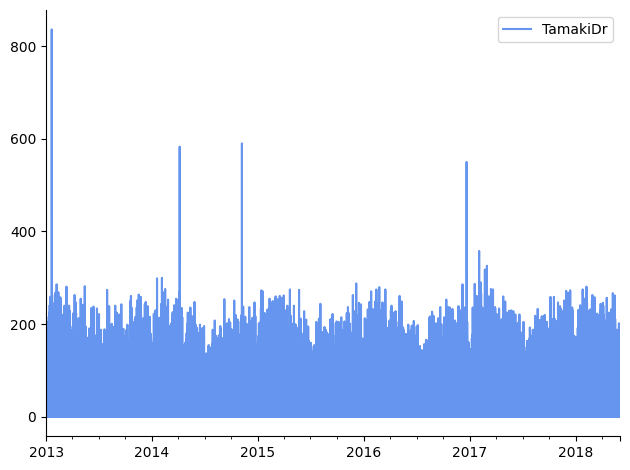

In [ ]:
# @title TamakiDr
# Adding Tamaki Drive Eastern Bound & Western Bound Together:
Tamaki=df.loc[:,'Tamaki Drive WB'] + df.loc[:,'Tamaki Drive EB']
# Restricting Period When Hourly Weather is Available:
Tamaki=Tamaki.loc['2013':'2018-06-01']
Tamaki=Tamaki.to_frame(name='TamakiDr')
Tamaki.plot(c='#6595EE')
sns.despine(     )
plt.xlabel(None  )
plt.tight_layout()
plt.show(        )

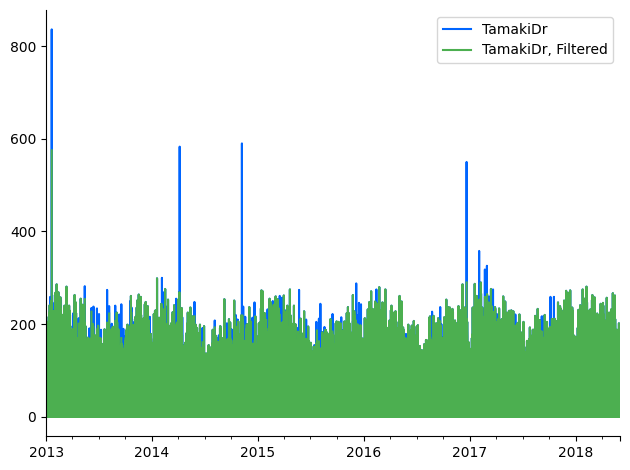

,0
TamakiDr,6
"TamakiDr, Filtered",229


In [ ]:
# @title TamakiDr, Filtered
# Getting Rid of OutLiers Using Median Filter:
def MedianFilter(df, varname=None, window=24, std=3):
    '''
    Simple Median Filter, removes (i.e., replace by np.nan) observations that exceed N (default=3)
    standard deviation from the median over window of length P (default=24) centered around
    each observation.
    Parameters:
    ----------
    df     : pandas.DataFrame – column to filter.
    varname: string           – column to filter in the pandas.DataFrame. No default.
    window : integer          – size of the window around each observation for the calculation of the median and std.
                                Default is 24 (time-steps).
    std    : integer          – threshold for the number of std around the median to replace by `np.nan`.
                                Default is  3 (greater/less or equal).
    Returns:
    -------
    dfc    : pandas.Dataframe – a copy of the pandas.DataFrame `df` with the new, filtered column `varname`.
    '''
    dfc=df.loc[:,[varname]]
    dfc['median']=dfc[varname].rolling(window, center=True).median()
    dfc['std'   ]=dfc[varname].rolling(window, center=True).std()
    dfc.loc[dfc.loc[:,varname]>=dfc['median']+std*dfc['std'], varname] = np.nan
    dfc.loc[dfc.loc[:,varname]<=dfc['median']-std*dfc['std'], varname] = np.nan
    return dfc.loc[:, varname]
dfc=Tamaki.copy()
dfc.loc[:,'TamakiDr, Filtered']=MedianFilter(dfc, varname='TamakiDr')
colors=['#0065FF','#4CAF50']
dfc.plot(color=colors)
sns.despine(     )
plt.xlabel(None  )
plt.tight_layout()
plt.show(        )
dfc.isnull().sum()

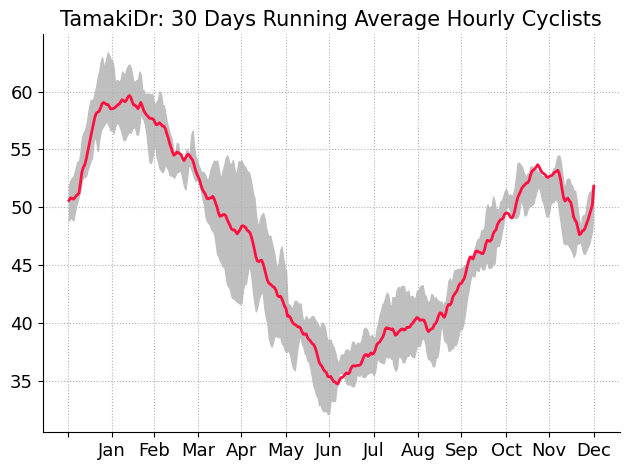

In [ ]:
# @title 30 Day Running Average
# Plotting Seasonal Cycle – Average & InterQuertile Range:
season_cycl=dfc.loc[:,'TamakiDr, Filtered'].rolling(window=30*24, center=True, min_periods=20).mean().groupby(dfc.index.dayofyear).mean()
q25        =dfc.loc[:,'TamakiDr, Filtered'].rolling(window=30*24, center=True, min_periods=20).mean().groupby(dfc.index.dayofyear).quantile(.25)
q75        =dfc.loc[:,'TamakiDr, Filtered'].rolling(window=30*24, center=True, min_periods=20).mean().groupby(dfc.index.dayofyear).quantile(.75)
# Tick & Ticks Labels:
ndays_m    =mdays.copy()
ndays_m[2] =29
ndays_m    =np.cumsum(ndays_m)
m_abbr     =month_abbr
# Plotting:
f,ax=plt.subplots()
season_cycl.plot(ax=ax, lw=2, color='#FF103F', legend=False)
ax.fill_between(season_cycl.index, q25.values.ravel(), q75.values.ravel(), color='.75')
ax.set_xticks(ndays_m)
ax.set_xticklabels(m_abbr)
ax.grid(ls=  ':')
ax.set_xlabel('')
ax.set_ylabel('')
[l.set_fontsize(13) for l in ax.xaxis.get_ticklabels()]
[l.set_fontsize(13) for l in ax.yaxis.get_ticklabels()]
ax.set_title('TamakiDr: 30 Days Running Average Hourly Cyclists', fontsize=15)
for ext in ['png','jpeg','pdf']: f.savefig(f'/content/SeasonalCycle.{ext}', dpi=200)
sns.despine(     )
plt.tight_layout()
plt.show(        )

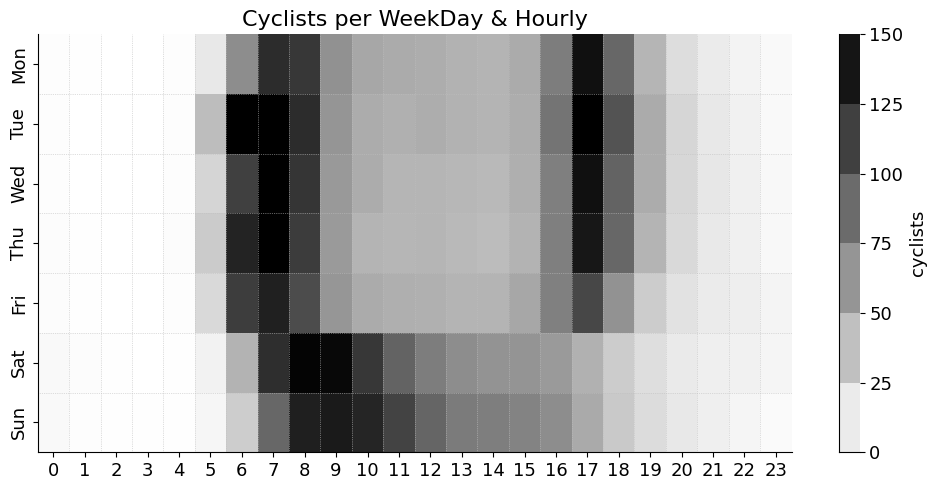

In [ ]:
# @title WeekDay Hourly
# Cyclists per WeekDay & Hourly:
WeekHour=dfc.loc[:,['TamakiDr, Filtered']].copy()
WeekHour.loc[:,'day_of_week']=WeekHour.index.dayofweek
WeekHour.loc[:,       'hour']=WeekHour.index.hour
WeekHour                     =WeekHour.groupby(['day_of_week','hour']).mean().unstack()
WeekHour.columns             =WeekHour.columns.droplevel(0)
# Plotting
f,ax=plt.subplots(figsize=(10,5))
sns.heatmap(WeekHour, ax = ax, cmap='binary', vmax=150, cbar_kws={'boundaries':np.arange(0,160,25)})  # plt.cm.gray_r
cbax=f.axes[1]
[l.set_fontsize(13) for l in cbax.yaxis.get_ticklabels()]
cbax.set_ylabel('cyclists', fontsize=13)
[ax.axhline(x, ls=':', lw=0.5, color='.75') for x in np.arange(1, 7)]
[ax.axvline(x, ls=':', lw=0.5, color='.75') for x in np.arange(1, 24)];
ax.set_title('Cyclists per WeekDay & Hourly', fontsize=16)
[l.set_fontsize(13) for l in ax.xaxis.get_ticklabels()]
[l.set_fontsize(13) for l in ax.yaxis.get_ticklabels()]
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_yticklabels(day_abbr[0:7])
for ext in ['png','jpeg','pdf']: f.savefig(f'/content/HourlyWeekDayCyclists.{ext}', dpi=200)
sns.despine(     )
plt.tight_layout()
plt.show(        )

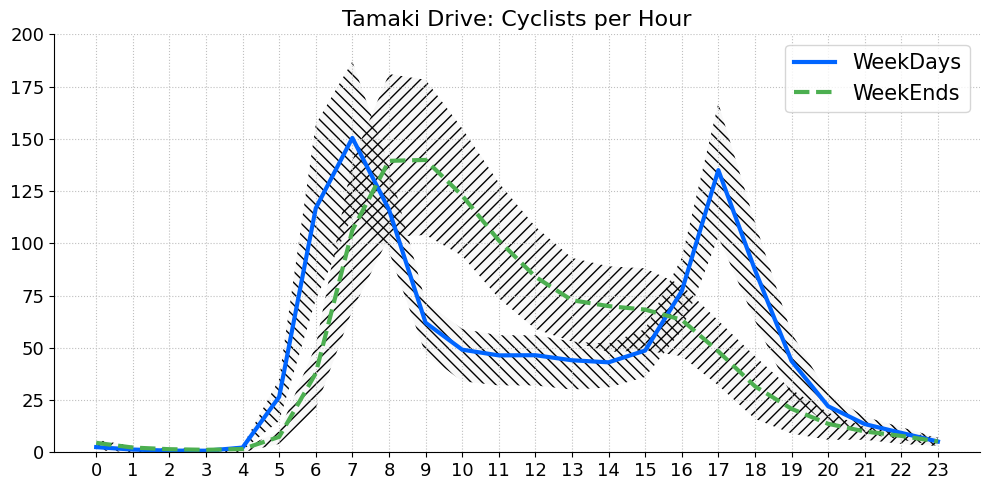

In [ ]:
# @title WeekDays × WeekEnds
weekdays=dfc.loc[dfc.index.day_name().isin(['Monday','Tuesday','Wednesday','Thursday','Friday']), 'TamakiDr, Filtered']
weekends=dfc.loc[dfc.index.day_name().isin(['Sunday','Saturday'])                               , 'TamakiDr, Filtered']
summaryHourWeekDays=weekdays.groupby(weekdays.index.hour).describe()
summaryHourWeekEnds=weekends.groupby(weekends.index.hour).describe()
# Plotting
f,ax=plt.subplots(figsize=(10,5))
ax.plot(summaryHourWeekDays.index, summaryHourWeekDays.loc[:,'mean'], color='#0065FF', label='WeekDays', lw=3)
ax.fill_between(summaryHourWeekDays.index, summaryHourWeekDays.loc[:,'25%'],
                summaryHourWeekDays.loc[:,'75%'], hatch='\\\\\\', facecolor='0.75', alpha=.1)
ax.plot(summaryHourWeekEnds.index, summaryHourWeekEnds.loc[:,'mean'], color='#4CAF50', label='WeekEnds', ls='--', lw=3)
ax.fill_between(summaryHourWeekEnds.index, summaryHourWeekEnds.loc[:,'25%'],
                summaryHourWeekEnds.loc[:,'75%'], hatch='///'   , facecolor='0.75', alpha=.1)
ax.legend(loc=1 , fontsize=15)
ax.grid(ls=':'  , color='.75')
ax.set_xticks(range(24))
ax.set_ylim([0, 200])
ax.set_xlabel('')
ax.set_ylabel('')
[l.set_fontsize(13) for l in ax.xaxis.get_ticklabels()]
[l.set_fontsize(13) for l in ax.yaxis.get_ticklabels()]
ax.set_title('Tamaki Drive: Cyclists per Hour', fontsize=16)
for ext in ['png','jpeg','pdf']: f.savefig(f'/content/DailyCycle.{ext}', dpi=200)
sns.despine(     )
plt.tight_layout()
plt.show(        )

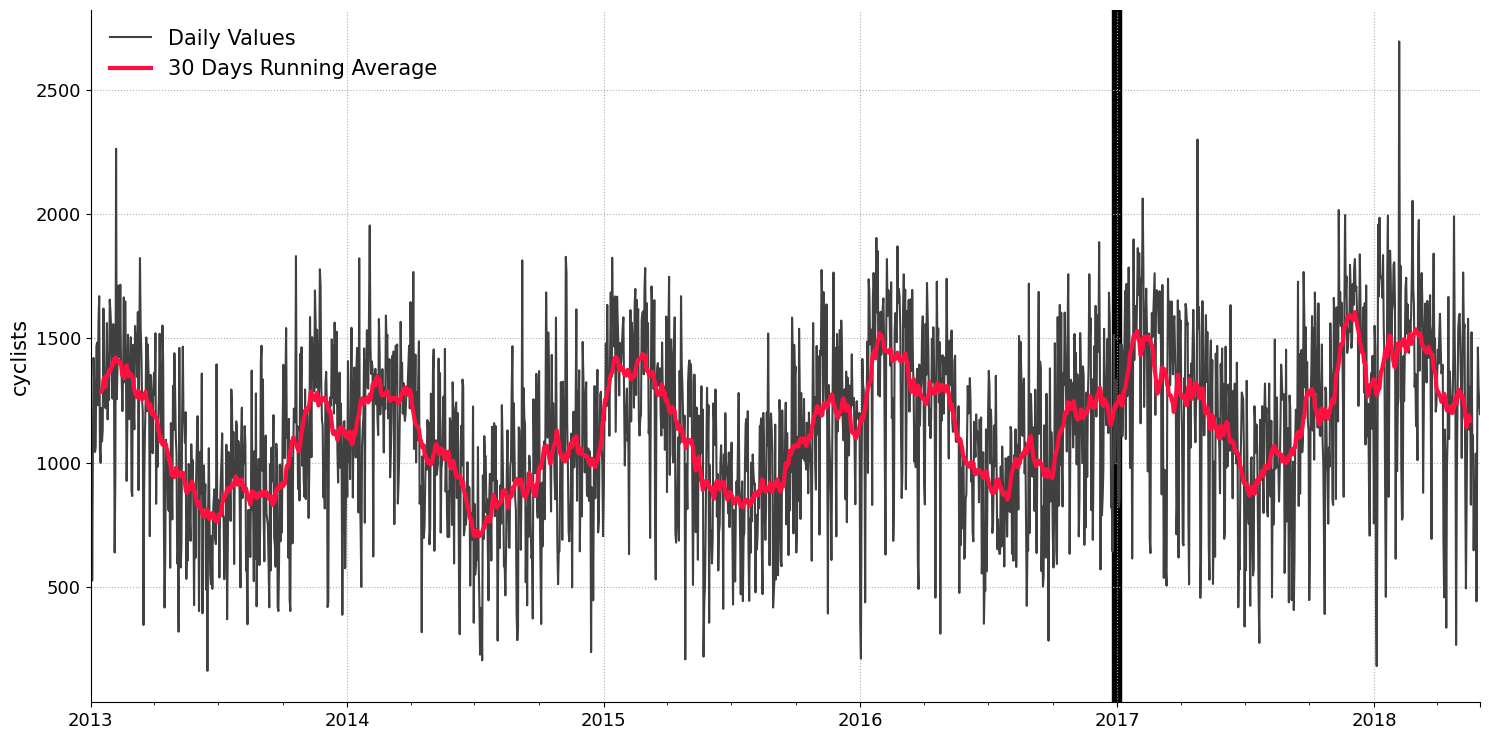

In [ ]:
# @title Daily Totals
# Calculating Daily Totals from Hourly Data:
data=dfc.loc['2013':,['TamakiDr, Filtered']].resample('1D').sum()
# Plotting Time Series:
# Train Set: 2013       to 2016       – 1461 days
# Test  Set: 2017.01.01 to 2018.05.31 –  516 days
# Vertical Bar Marks the Separation Between Training & Test Sets
f,ax=plt.subplots(figsize=(15,7.5))
data.plot(ax=ax, color='.25')
data.rolling(window=30, center=True).mean().plot(ax=ax, ls='-', lw=3, color='#FF103F')
ax.axvline('2017', color= ' 0', lw=7.5, zorder=-1)
ax.legend(['Daily Values','30 Days Running Average'], frameon=False, fontsize=15)
[l.set_fontsize(13) for l in ax.xaxis.get_ticklabels()]
[l.set_fontsize(13) for l in ax.yaxis.get_ticklabels()]
ax.set_ylabel('cyclists', fontsize=15);
ax.set_xlabel('')
ax.grid(ls=':')
for ext in ['png','jpeg','pdf']: f.savefig(f'/content/CyclistsTamakiDr.{ext}', dpi=200)
sns.despine(     )
plt.tight_layout()
plt.show(        )

In [ ]:
# @title Holidays
HoliDays=pd.DataFrame([], columns=['ds','holiday'])
Dates=[]
Names=[]
for date, name in sorted(holidays.NZ(prov='AUK', years=np.arange(2013, 2018 + 1)).items()):
    Dates.append(         date)
    Names.append(         name)
Dates=np.array(           Dates)
Names=np.array(           Names)
HoliDays.loc[:,     'ds']=Dates
HoliDays.loc[:,'holiday']=Names
HoliDays.holiday.unique()

array(["New Year's Day", "Day after New Year's Day",
       'Auckland Anniversary Day', 'Waitangi Day', 'Good Friday',
       'Easter Monday', 'Anzac Day', "Queen's Birthday", 'Labour Day',
       'Christmas Day', 'Boxing Day', 'Anzac Day (observed)',
       'Boxing Day (observed)', "Day after New Year's Day (observed)",
       'Waitangi Day (observed)', 'Christmas Day (observed)',
       "New Year's Day (observed)"], dtype=object)

In [ ]:
# Conflating Actual & Observed Ones to Reduce Categories:
HoliDays.loc[:,'holiday']=HoliDays.loc[:,'holiday'].apply(lambda x: x.replace(' (observed)',''))
HoliDays.holiday.unique()

array(["New Year's Day", "Day after New Year's Day",
       'Auckland Anniversary Day', 'Waitangi Day', 'Good Friday',
       'Easter Monday', 'Anzac Day', "Queen's Birthday", 'Labour Day',
       'Christmas Day', 'Boxing Day'], dtype=object)

In [ ]:
# Preparing Cycling Count for ProPhet:
data=data.rename({'TamakiDr, Filtered':'y'}, axis=1)
data#.head()

,y
datetime,
2013-01-01,1163.0
2013-01-02,1112.0
2013-01-03,527.0
2013-01-04,1045.0
2013-01-05,1422.0
...,...
2018-05-28,1107.0
2018-05-29,1464.0
2018-05-30,1298.0


In [ ]:
# Train & Test Split:
def PrepareData(data, year):
    '''
    Prepare Data for ProPhet:
    1) Train & Test Split, using the `year` parameter (int)
    2) Reset Index & ReName `DateTime` column to `ds`
    returns training & test dataframes
    Parameters:
    ----------
    data: pandas.DataFrame to prepare, needs to have a datetime index
    year: integer – year separating the training set and the test set (includes the year)
    Returns:
    -------
    train: pandas.DataFrame – training set, formatted for ProPhet.
    test : pandas.Dataframe – test     set, formatted for ProPhet.
    '''
    train=data.loc[:str(year - 1),:]
    test =data.loc[ str(year   ):,:]
    train.reset_index(inplace=True)
    test.reset_index( inplace=True)
    train=train.rename({'datetime':'ds'}, axis=1)
    test =test.rename( {'datetime':'ds'}, axis=1)
    return train, test
train, test = PrepareData(data, 2017)
train.head(), test.head()

(          ds       y
 0 2013-01-01  1163.0
 1 2013-01-02  1112.0
 2 2013-01-03   527.0
 3 2013-01-04  1045.0
 4 2013-01-05  1422.0,
           ds       y
 0 2017-01-01  1245.0
 1 2017-01-02   956.0
 2 2017-01-03   823.0
 3 2017-01-04   853.0
 4 2017-01-05  1476.0)

In [ ]:
# @title No Climate Model
# Model Instance & Fitting:
model=Prophet(mcmc_samples           =300,
              holidays               =HoliDays,
              holidays_prior_scale   =.25,
              changepoint_prior_scale=.01,
              seasonality_mode       ='multiplicative',
              yearly_seasonality     = 10,
              weekly_seasonality     = True,
              daily_seasonality      =False)
model.fit(train)

DEBUG:cmdstanpy:cmd: /usr/local/lib/python3.10/dist-packages/prophet/stan_model/prophet_model.bin info
cwd: None
DEBUG:cmdstanpy:input tempfile: /tmp/tmp2hzbw8c_/b4n4ukdn.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp2hzbw8c_/l3l4ehrm.json
09:44:22 - cmdstanpy - INFO - CmdStan start processing
INFO:cmdstanpy:CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: 1
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.10/dist-packages/prophet/stan_model/prophet_model.bin', 'id=1', 'random', 'seed=67982', 'data', 'file=/tmp/tmp2hzbw8c_/b4n4ukdn.json', 'init=/tmp/tmp2hzbw8c_/l3l4ehrm.json', 'output', 'file=/tmp/tmp2hzbw8c_/prophet_modelv38qyfze/prophet_model-20241029094423_1.csv', 'method=sample', 'num_samples=150', 'num_warmup=150', 'algorithm=hmc', 'adapt', 'engaged=1']
DEBUG:cmdstanpy:idx 1
DEBUG:cmdstanpy:running CmdStan, num_threads: 1
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.10/dist-packages/prophet/stan_model/prophet_model.bin', 'id=2', 'random', 'seed=67982', 'data', 'file=/tmp/tmp2hzbw8c_/b4n4ukdn.json', 'init=/tmp/tmp2hzbw8c_/l3l4ehrm.json', 'output', 'file=/tmp/tmp2hzbw8c_/prophet_modelv38qyfze/prophet_model-20241029094423_2.csv', 'method=sample', 'num_samples=150', 'num_warmup=150', 'algorithm=hmc', 'adapt', 'engaged=1']
DEBUG:cmdstanpy:idx 2
DEBUG:cmds

09:45:42 - cmdstanpy - INFO - CmdStan done processing.
INFO:cmdstanpy:CmdStan done processing.
DEBUG:cmdstanpy:runset
RunSet: chains=4, chain_ids=[1, 2, 3, 4], num_processes=4
 cmd (chain 1):
	['/usr/local/lib/python3.10/dist-packages/prophet/stan_model/prophet_model.bin', 'id=1', 'random', 'seed=67982', 'data', 'file=/tmp/tmp2hzbw8c_/b4n4ukdn.json', 'init=/tmp/tmp2hzbw8c_/l3l4ehrm.json', 'output', 'file=/tmp/tmp2hzbw8c_/prophet_modelv38qyfze/prophet_model-20241029094423_1.csv', 'method=sample', 'num_samples=150', 'num_warmup=150', 'algorithm=hmc', 'adapt', 'engaged=1']
 retcodes=[0, 0, 0, 0]
 per-chain output files (showing chain 1 only):
 csv_file:
	/tmp/tmp2hzbw8c_/prophet_modelv38qyfze/prophet_model-20241029094423_1.csv
 console_msgs (if any):
	/tmp/tmp2hzbw8c_/prophet_modelv38qyfze/prophet_model-20241029094423_0-stdout.txt
DEBUG:cmdstanpy:Chain 1 console:
method = sample (Default)
  sample
    num_samples = 150
    num_warmup = 150
    save_warmup = 0 (Default)
    thin = 1 (Defau

In [ ]:
# Future DataFrame:
future=model.make_future_dataframe(periods=len(test), freq='1D')
future

,ds
0,2013-01-01
1,2013-01-02
2,2013-01-03
3,2013-01-04
4,2013-01-05
...,...
1973,2018-05-28
1974,2018-05-29
1975,2018-05-30
1976,2018-05-31


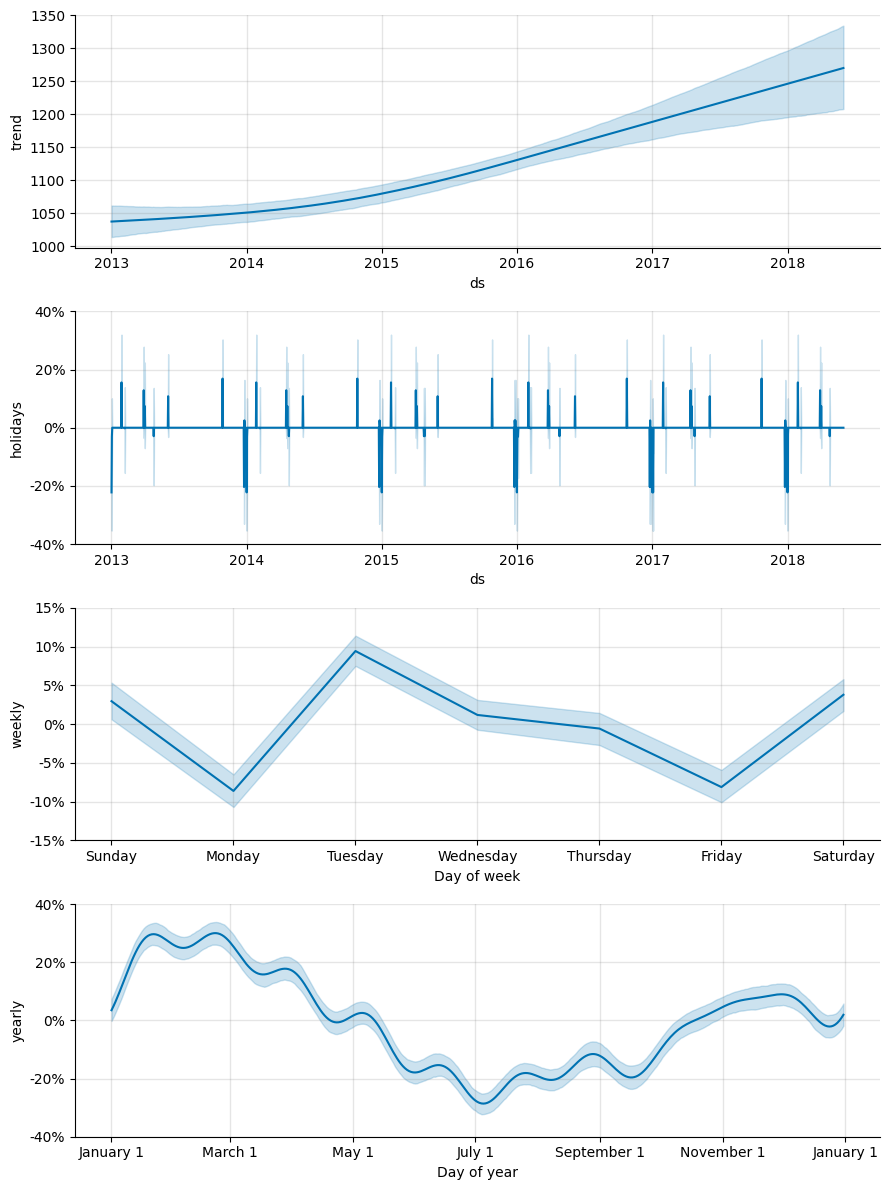

In [ ]:
# ForeCast
forecast=model.predict( future  )
f=model.plot_components(forecast)
sns.despine(     )
plt.tight_layout()
plt.show(        )

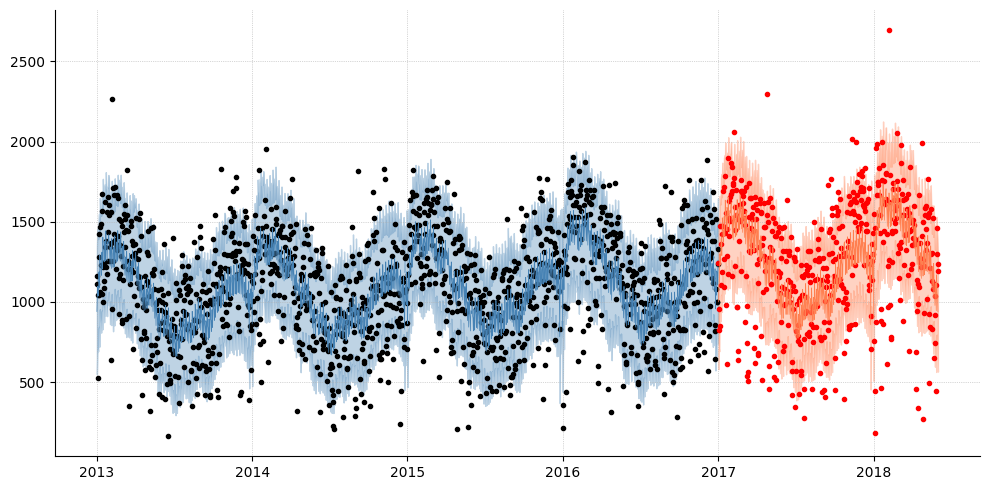

In [ ]:
# Putting It All Together with Actual Observations:
def Verif(forecast, train, test):
    '''
    Put together the forecast (from ProPhet) and the overved data,
    and set the index to be a proper datetime index, for plotting.
    Parameters:
    ----------
    forecast: pandas.DataFrame coming from the `forecast` method of the ProPhet model.
    train   : pandas.DataFrame – training set.
    test    : pandas.DataFrame – test     set.
    Returns:
    -------
    forecast: forecast DataFrame including the original observed data.
    '''
    forecast.index=pd.to_datetime(forecast.ds)
    train.index   =pd.to_datetime(   train.ds)
    test.index    =pd.to_datetime(    test.ds)
    data          =pd.concat([train, test], axis=0)
    forecast.loc[:,'y'] = data.loc[:,'y']
    return forecast
verif=Verif(forecast, train, test)
def PlotVerif(verif, year):
    '''
    Plot the forecasts and the observed data,
    `year` argument is used to visualise the division between training & test sets.
    Parameters:
    ----------
    verif: pandas.DataFrame – `verif` DataFrame coming from `Verif` function.
    year : integer          –  year used to separate training & test sets.
    Returns:
    -------
    f    : matplotlib Figure object.
    '''
    f,ax =plt.subplots(figsize=(10,5))
    train=verif.loc[:str(year - 1),:]
    ax.plot(train.index, train.y, 'ko', markersize=3)
    ax.plot(train.index, train.yhat, color='steelblue', lw= .5)
    ax.fill_between(train.index, train.yhat_lower, train.yhat_upper, color='steelblue', alpha=.35)
    test=verif.loc[str(year):,:]
    ax.plot(test.index,   test.y, 'ro', markersize=3)
    ax.plot(test.index,   test.yhat, color='coral'    , lw= .5)
    ax.fill_between( test.index,  test.yhat_lower,  test.yhat_upper, color='coral',     alpha=.35)
   #ax.axvline(str(year),                                            color='.75'  ,     alpha=.75)
   #ax.axvline(   '2017'                              , lw=7.5,      color='.75'  ,    zorder=- 1)
    ax.grid(ls=':'                                    , lw= .5)
    sns.despine(     )
    plt.tight_layout()
    plt.show(        )
    return f
f=PlotVerif(verif, 2017)

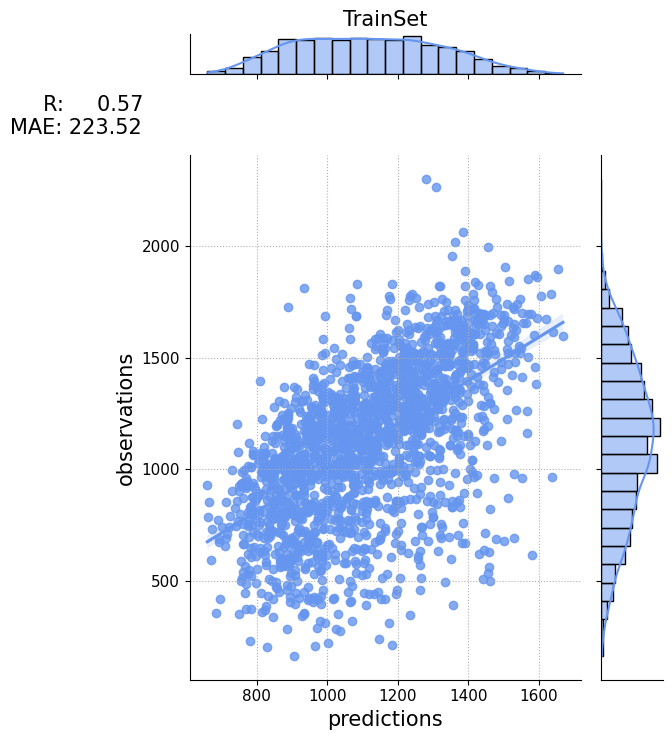

In [ ]:
# Scatter Plot & Marginal Distribution & Correlation Between Observations & Modelled/Predicted Values:
def JointPlots(verif, x='yhat', y='y', title=None, fpath = '/content', fname = None):
    '''
    Parameters:
    ----------
    verif: pandas.DataFrame
    x    : string – the variable on the x-axis
           Defaults to `yhat` (forecast or estimated value).
    y    : string – the variable on the y-axis
           Defaults to `y`    (             observed value).
    title: string – the title of the figure, default `None`.
    fpath: string – the path to save the figures, default to `/content`
    fname: string – the filename for the figure to be saved,
           ommiting the extension; figure is saved in png, jpeg and pdf
    Returns:
    -------
    f    : matplotlib Figure object
    '''
    g=sns.jointplot(x='yhat', y='y', data=verif, kind='reg', color='#6595EE')#.35
    g.fig.set_figwidth( 7.5)
    g.fig.set_figheight(7.5)
    ax= g.fig.axes[1]
    if title is not None: ax.set_title(title, fontsize=15)
    ax= g.fig.axes[0]
    ax.set_xlim()#[0, 1800]
    ax.set_ylim()#[0, 3000]
    ax.text(   100, 2500, '     R:     {:.2f}\nMAE: {:.2f}'.format(verif.loc[:,['y','yhat']].corr().iloc[0,1], MAE(verif.loc[:,'y'].values, verif.loc[:,'yhat'].values)), fontsize=15)
    ax.set_ylabel('observations', fontsize=15)
    ax.set_xlabel('predictions' , fontsize=15)
    [l.set_fontsize(11) for l in ax.xaxis.get_ticklabels()]
    [l.set_fontsize(11) for l in ax.yaxis.get_ticklabels()]
    ax.grid(ls=':')
    sns.despine(     )
    plt.tight_layout()
    plt.show(        )
    if fname is not None:
        for ext in ['png','jpeg','pdf']:
            g.fig.savefig(os.path.join(fpath, "{}.{}".format(fname, ext)), dpi=200)
JointPlots(verif.loc[:'2017',:], title='TrainSet', fname='TrainSetJointPlotNoClimate')

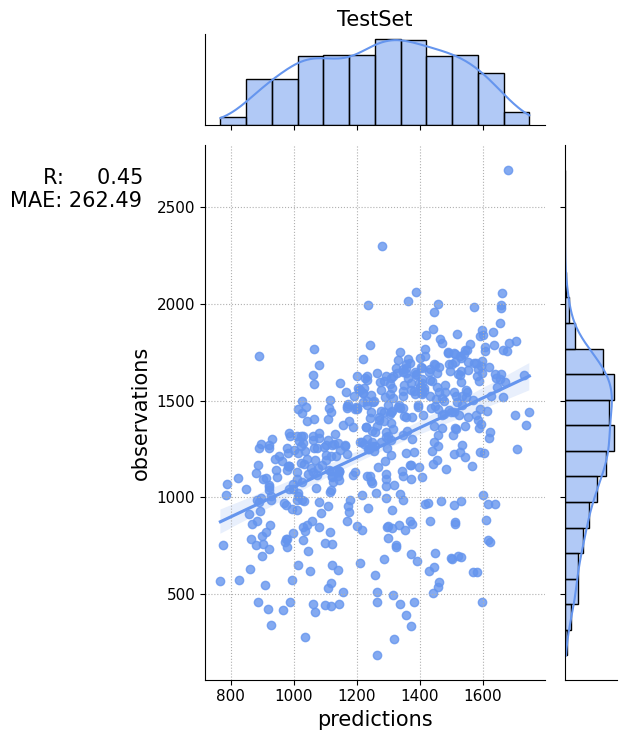

In [ ]:
# Test Set:
JointPlots(verif.loc['2017':,:], title='TestSet', fname='TestSetJointPlotNoClimate')

In [ ]:
# Correlation:
verif.loc['2017':,['y','yhat']].corr()

,y,yhat
y,1.000000,0.453193
yhat,0.453193,1.000000


In [ ]:
# MAE in Number of Cyclists:
round(MAE(verif.loc['2017':,'y'].values, verif.loc['2017':,'yhat'].values), 2)

262.49

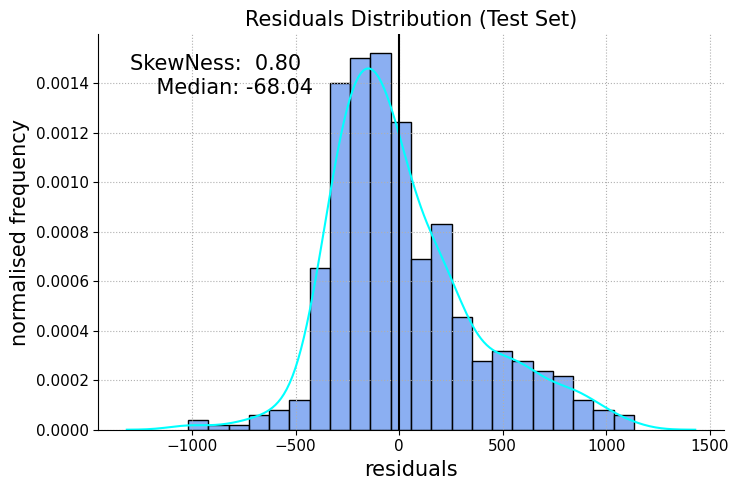

In [ ]:
# @title KDE
f,ax=plt.subplots(figsize=(7.5,5))
sns.histplot((verif.loc['2017':,'yhat'] - verif.loc['2017':,'y']), ax=ax, color='#6595EE', kde=False, stat='density')
sns.kdeplot( (verif.loc['2017':,'yhat'] - verif.loc['2017':,'y']), ax=ax, color='#00FFFF')
ax.set_xlabel('residuals'           , fontsize=15)
ax.set_ylabel('normalised frequency', fontsize=15)
ax.grid(ls=':')
[l.set_fontsize(11) for l in ax.xaxis.get_ticklabels()]
[l.set_fontsize(11) for l in ax.yaxis.get_ticklabels()]
ax.text(.05, .85, 'SkewNess:  {:.2f}\n    Median: {:.2f}'.
        format(skew(verif.loc['2017':,'yhat'] - verif.loc['2017':,'y']),
                   (verif.loc['2017':,'yhat'] - verif.loc['2017':,'y']).median()),
        fontsize=15, transform=ax.transAxes)
ax.axvline(0, color='.001')
ax.set_title('Residuals Distribution (Test Set)', fontsize=15)
sns.despine(     )
plt.tight_layout()
plt.show(        )
for ext in ['png','jpeg','pdf']: f.savefig(f'/content/ResidualsDistributionTestSetNoClimate.{ext}', dpi=200)

In [ ]:
# @title Weather
# Incorporating Weather Conditions
# Adding daytime (i.e., 6 AM to 9 PM) averaged temperature, rainfall, sunshine fraction and windspeed
# as extra regressors in the ProPhet Model
# Temperature:
temp=  pd.read_csv('https://github.com/nicolasfauchereau/Auckland_Cycling/raw/refs/heads/master/data/weather/hourly/commute/temp_day.csv', index_col=0, parse_dates=True)
temp=temp.loc[:,['Tmin(C)']]
temp.columns=['temp']
temp#.head()

,temp
2012-01-01,19.807143
2012-01-02,18.000000
2012-01-03,19.335714
2012-01-04,19.307143
2012-01-05,19.978571
...,...
2018-08-04,9.721429
2018-08-05,10.907143
2018-08-06,11.557143
2018-08-07,12.014286


In [ ]:
# RainFall:
rain=  pd.read_csv('https://github.com/nicolasfauchereau/Auckland_Cycling/raw/refs/heads/master/data/weather/hourly/commute/rain_day.csv', index_col=0, parse_dates=True)
rain=rain.loc[:,['Amount(mm)']]
rain.columns=['rain']
rain#.head()

,rain
2012-01-01,0.000000
2012-01-02,0.000000
2012-01-03,0.028571
2012-01-04,0.185714
2012-01-05,0.014286
...,...
2018-08-04,0.000000
2018-08-05,0.057143
2018-08-06,0.000000
2018-08-07,0.000000


In [ ]:
# SunShine Fraction:
sun=pd.read_csv('https://github.com/nicolasfauchereau/Auckland_Cycling/raw/refs/heads/master/data/weather/hourly/commute/sun_day.csv', index_col=0, parse_dates=True)
sun.columns=['sun']
sun#.head()

,sun
2012-01-01,0.078571
2012-01-02,0.128571
2012-01-03,0.321429
2012-01-04,0.128571
2012-01-05,0.378571
...,...
2018-08-04,0.664286
2018-08-05,0.035714
2018-08-06,0.335714
2018-08-07,0.607143


In [ ]:
# Wind:
wind=  pd.read_csv('https://github.com/nicolasfauchereau/Auckland_Cycling/raw/refs/heads/master/data/weather/hourly/commute/wind_day.csv', index_col=0, parse_dates=True)
wind=wind.loc[:,['Speed(m/s)']]
wind.columns=['wind']
wind#.head()

,wind
2011-01-01,8.464286
2011-01-02,3.857143
2011-01-03,3.871429
2011-01-04,2.392857
2011-01-05,6.621429
...,...
2018-05-28,3.200000
2018-05-29,2.571429
2018-05-30,2.378571
2018-05-31,2.057143


In [ ]:
# Restricting Available Period:
temp=temp.loc['2013': '2018-06-01', :]
rain=rain.loc['2013': '2018-06-01', :]
sun = sun.loc['2013': '2018-06-01', :]
wind=wind.loc['2013': '2018-06-01', :]
# InterPolating to Remove Missing Values:
temp=temp.interpolate(method='linear')
rain=rain.interpolate(method='linear')
sun = sun.interpolate(method='linear')
wind=wind.interpolate(method='linear')
# Adding Climate Regressors:
def AddRegressor(data, regressor, varname=None):
    '''
    Adds a regressor to `pandas.DataFrame` of target (predictand) values for use in ProPhet.
    Parameters:
    ----------
    data     : pandas.DataFrame from function `PrepareData`.
    regressor: pandas.DataFrame – extra-regressor.
    varname  : string           – name of the column in the `regressor` DataFrame to add to the `data` DataFrame.
    Returns:
    -------
    verif    : pandas.DataFrame – original `data` DataFrame with the column containing the extra regressor `varname`
    '''
    data_with_regressors=data.copy()
    data_with_regressors.loc[:,varname]=regressor.loc[:,varname]
    return data_with_regressors
data_with_regressors=AddRegressor(data,                 temp, varname='temp')
data_with_regressors=AddRegressor(data_with_regressors, rain, varname='rain')
data_with_regressors=AddRegressor(data_with_regressors, sun , varname='sun' )
data_with_regressors=AddRegressor(data_with_regressors, wind, varname='wind')
data_with_regressors#.head()

,y,temp,rain,sun,wind
datetime,,,,,
2013-01-01,1163.0,20.000000,0.000000,0.950000,6.100000
2013-01-02,1112.0,20.342857,0.000000,0.535714,4.428571
2013-01-03,527.0,16.278571,0.228571,0.014286,4.728571
2013-01-04,1045.0,17.635714,0.000000,0.742857,8.978571
2013-01-05,1422.0,19.592857,0.000000,0.964286,6.185714
...,...,...,...,...,...
2018-05-28,1107.0,8.750000,0.000000,0.271429,3.200000
2018-05-29,1464.0,7.764286,0.000000,0.671429,2.571429
2018-05-30,1298.0,7.614286,0.000000,0.621429,2.378571


In [ ]:
# @title Climate Model
# Preparing Data & SubSets (Train & Test):
train, test=PrepareData(data_with_regressors, 2017)
train.head(), test.head()

(          ds       y       temp      rain       sun      wind
 0 2013-01-01  1163.0  20.000000  0.000000  0.950000  6.100000
 1 2013-01-02  1112.0  20.342857  0.000000  0.535714  4.428571
 2 2013-01-03   527.0  16.278571  0.228571  0.014286  4.728571
 3 2013-01-04  1045.0  17.635714  0.000000  0.742857  8.978571
 4 2013-01-05  1422.0  19.592857  0.000000  0.964286  6.185714,
           ds       y       temp      rain       sun       wind
 0 2017-01-01  1245.0  20.650000  0.000000  0.464286   5.228571
 1 2017-01-02   956.0  20.371429  0.014286  0.007143   5.900000
 2 2017-01-03   823.0  20.364286  0.192857  0.021429   7.585714
 3 2017-01-04   853.0  17.314286  0.000000  0.285714  10.407143
 4 2017-01-05  1476.0  17.407143  0.000000  0.964286   5.842857)

In [ ]:
# New Model:
model=Prophet(mcmc_samples           =300,
              holidays               =HoliDays,
              holidays_prior_scale   =.25,
              changepoint_prior_scale=.01,
              seasonality_mode       ='multiplicative',
              yearly_seasonality     = 10,
              weekly_seasonality     = True,
              daily_seasonality      =False)
model.add_regressor('temp', prior_scale=.5, mode='multiplicative')
model.add_regressor('rain', prior_scale=.5, mode='multiplicative')
model.add_regressor('sun' , prior_scale=.5, mode='multiplicative')
model.add_regressor('wind', prior_scale=.5, mode='multiplicative')
model.fit(train)

DEBUG:cmdstanpy:cmd: /usr/local/lib/python3.10/dist-packages/prophet/stan_model/prophet_model.bin info
cwd: None
DEBUG:cmdstanpy:input tempfile: /tmp/tmp2hzbw8c_/jkmlha7h.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp2hzbw8c_/13zkihd0.json
09:45:55 - cmdstanpy - INFO - CmdStan start processing
INFO:cmdstanpy:CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: 1
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.10/dist-packages/prophet/stan_model/prophet_model.bin', 'id=1', 'random', 'seed=16279', 'data', 'file=/tmp/tmp2hzbw8c_/jkmlha7h.json', 'init=/tmp/tmp2hzbw8c_/13zkihd0.json', 'output', 'file=/tmp/tmp2hzbw8c_/prophet_modeltppvxzgb/prophet_model-20241029094555_1.csv', 'method=sample', 'num_samples=150', 'num_warmup=150', 'algorithm=hmc', 'adapt', 'engaged=1']
DEBUG:cmdstanpy:idx 1
DEBUG:cmdstanpy:running CmdStan, num_threads: 1
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.10/dist-packages/prophet/stan_model/prophet_model.bin', 'id=2', 'random', 'seed=16279', 'data', 'file=/tmp/tmp2hzbw8c_/jkmlha7h.json', 'init=/tmp/tmp2hzbw8c_/13zkihd0.json', 'output', 'file=/tmp/tmp2hzbw8c_/prophet_modeltppvxzgb/prophet_model-20241029094555_2.csv', 'method=sample', 'num_samples=150', 'num_warmup=150', 'algorithm=hmc', 'adapt', 'engaged=1']
DEBUG:cmdstanpy:idx 2
DEBUG:cmds

09:46:56 - cmdstanpy - INFO - CmdStan done processing.
INFO:cmdstanpy:CmdStan done processing.
DEBUG:cmdstanpy:runset
RunSet: chains=4, chain_ids=[1, 2, 3, 4], num_processes=4
 cmd (chain 1):
	['/usr/local/lib/python3.10/dist-packages/prophet/stan_model/prophet_model.bin', 'id=1', 'random', 'seed=16279', 'data', 'file=/tmp/tmp2hzbw8c_/jkmlha7h.json', 'init=/tmp/tmp2hzbw8c_/13zkihd0.json', 'output', 'file=/tmp/tmp2hzbw8c_/prophet_modeltppvxzgb/prophet_model-20241029094555_1.csv', 'method=sample', 'num_samples=150', 'num_warmup=150', 'algorithm=hmc', 'adapt', 'engaged=1']
 retcodes=[0, 0, 0, 0]
 per-chain output files (showing chain 1 only):
 csv_file:
	/tmp/tmp2hzbw8c_/prophet_modeltppvxzgb/prophet_model-20241029094555_1.csv
 console_msgs (if any):
	/tmp/tmp2hzbw8c_/prophet_modeltppvxzgb/prophet_model-20241029094555_0-stdout.txt
DEBUG:cmdstanpy:Chain 1 console:
method = sample (Default)
  sample
    num_samples = 150
    num_warmup = 150
    save_warmup = 0 (Default)
    thin = 1 (Defau

In [ ]:
# Future DataFrame:
future=model.make_future_dataframe(periods=len(test), freq='1D')
future

,ds
0,2013-01-01
1,2013-01-02
2,2013-01-03
3,2013-01-04
4,2013-01-05
...,...
1973,2018-05-28
1974,2018-05-29
1975,2018-05-30
1976,2018-05-31


In [ ]:
# Adding Extra-Regressors Observed Over Future DataFrame Period:
def AddRegressorToFuture(future, regressor_df):
    '''
    Adds Extra Regressors to a `future` DataFrame Created by ProPhet.
    Parameters:
    ----------
    data        : pandas.DataFrame –`future` DataFrame created by ProPhet `make_future` method.
    regressor_df: pandas.DataFrame – regressors (with datetime index).
    Returns:
    -------
    futures     : pandas.DataFrame –`future` DataFrame with the regressors added.
    '''
    futures  =future.copy()
    futures.index=pd.to_datetime(futures.ds)
    regressor=    pd.concat(regressor_df, axis=1)
    futures  =futures.merge(regressor, left_index=True, right_index=True)
    futures  =futures.reset_index(           drop=True)
    return futures
futures=AddRegressorToFuture(future, [temp, rain, sun, wind])
futures#.head()

,ds,temp,rain,sun,wind
0,2013-01-01,20.000000,0.000000,0.950000,6.100000
1,2013-01-02,20.342857,0.000000,0.535714,4.428571
2,2013-01-03,16.278571,0.228571,0.014286,4.728571
3,2013-01-04,17.635714,0.000000,0.742857,8.978571
4,2013-01-05,19.592857,0.000000,0.964286,6.185714
...,...,...,...,...,...
1973,2018-05-28,8.750000,0.000000,0.271429,3.200000
1974,2018-05-29,7.764286,0.000000,0.671429,2.571429
1975,2018-05-30,7.614286,0.000000,0.621429,2.378571
1976,2018-05-31,8.192857,0.000000,0.678571,2.057143


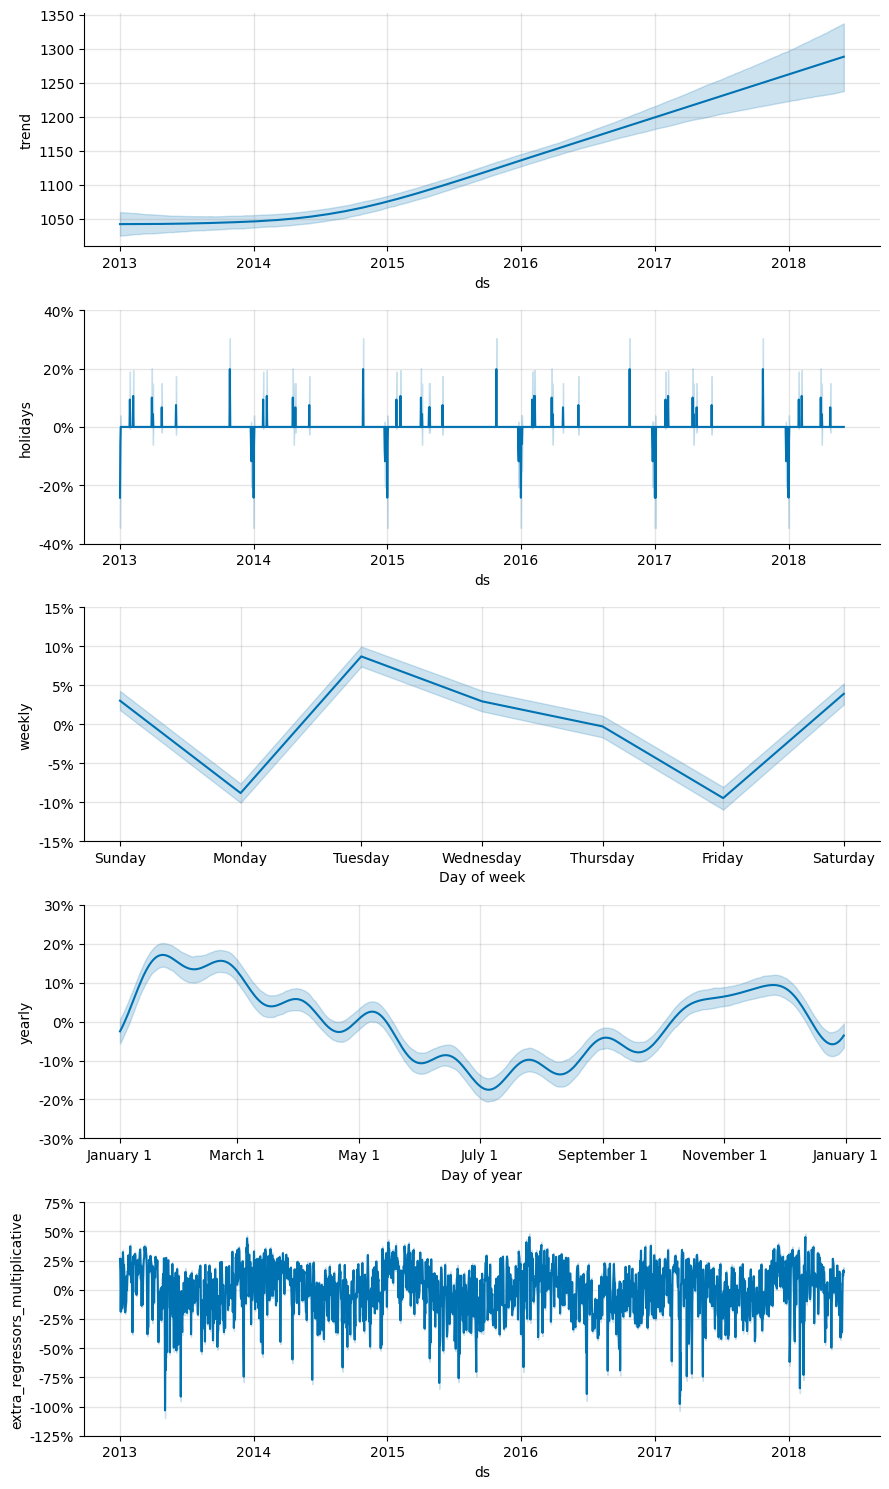

In [ ]:
# ForeCast Using Extra-Regressors as Predictors:
forecast=model.predict( futures )
# Components Ploting:
f=model.plot_components(forecast)
sns.despine(     )
plt.tight_layout()
plt.show(        )

In [ ]:
# Verif Pandas DataFrame:
verif=Verif(forecast, train, test)
# verif.drop(['ds'], axis=1, inplace=True)
verif#.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,Anzac Day,Anzac Day_lower,Anzac Day_upper,Auckland Anniversary Day,...,wind_lower,wind_upper,yearly,yearly_lower,yearly_upper,additive_terms,additive_terms_lower,additive_terms_upper,yhat,y
ds,,,,,,,,,,,,,,,,,,,,,
2013-01-01,2013-01-01,1042.407726,886.598070,1392.993987,1025.366183,1059.955330,0.0,0.0,0.0,0.0,...,-0.046648,-0.041398,-0.025099,-0.056411,0.006422,0.0,0.0,0.0,1128.972283,1163.0
2013-01-02,2013-01-02,1042.408693,912.461739,1407.736537,1025.448374,1059.926152,0.0,0.0,0.0,0.0,...,0.023566,0.026555,-0.015319,-0.046362,0.015687,0.0,0.0,0.0,1158.285302,1112.0
2013-01-03,2013-01-03,1042.409661,612.892496,1075.280011,1025.530564,1059.917037,0.0,0.0,0.0,0.0,...,0.011906,0.013416,-0.004562,-0.034917,0.026820,0.0,0.0,0.0,838.842536,527.0
2013-01-04,2013-01-04,1042.410629,743.431339,1212.401867,1025.612754,1059.919267,0.0,0.0,0.0,0.0,...,-0.172719,-0.153282,0.007025,-0.023313,0.038382,0.0,0.0,0.0,976.302687,1045.0
2013-01-05,2013-01-05,1042.411596,1138.486463,1597.724611,1025.694944,1059.921496,0.0,0.0,0.0,0.0,...,-0.050402,-0.044730,0.019282,-0.011891,0.049627,0.0,0.0,0.0,1375.533722,1422.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018-05-28,2018-05-28,1287.380898,742.307517,1226.680769,1237.159824,1335.894444,0.0,0.0,0.0,0.0,...,0.071318,0.080361,-0.097235,-0.124816,-0.069889,0.0,0.0,0.0,981.465007,1107.0
2018-05-29,2018-05-29,1287.553344,1193.665396,1688.498973,1237.226933,1336.174317,0.0,0.0,0.0,0.0,...,0.095749,0.107891,-0.101043,-0.128302,-0.073605,0.0,0.0,0.0,1446.645423,1464.0
2018-05-30,2018-05-30,1287.725791,1112.092950,1598.874323,1237.349705,1336.414804,0.0,0.0,0.0,0.0,...,0.103245,0.116337,-0.103906,-0.130410,-0.076817,0.0,0.0,0.0,1348.552564,1298.0


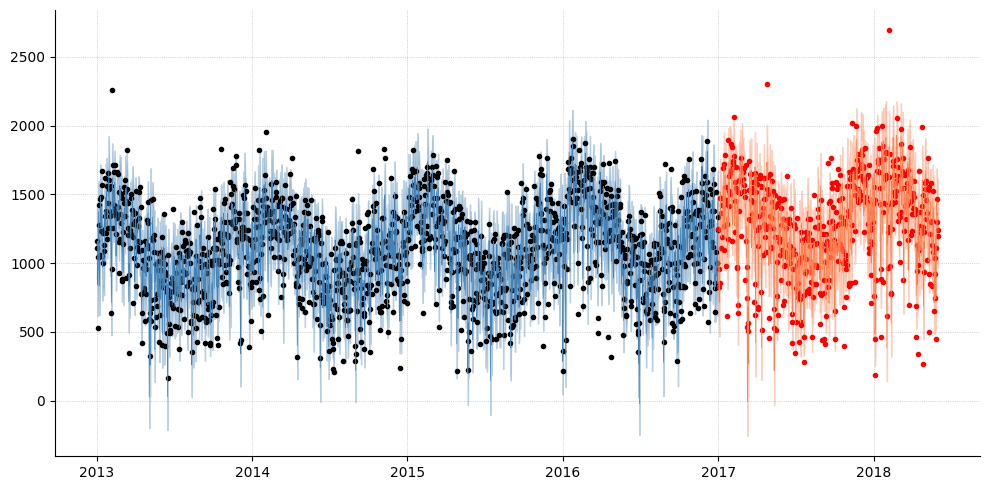

<Figure size 640x480 with 0 Axes>

In [ ]:
# Clips ForeCast so that no Values are Negative (Cannot Have egatie Numbers of Cyclists!):
# verif.loc[:,'yhat'] = verif.yhat.clip_lower(0)
# verif.loc[:,'yhat'      ]=verif.yhat.clip(      lower=True)
# verif.loc[:,'yhat_lower'] = verif.yhat_lower.clip_lower(0)
# verif.loc[:,'yhat_lower']=verif.yhat_lower.clip(lower=True)
f=PlotVerif(verif, 2017)
sns.despine(     )
plt.tight_layout()
plt.show(        )

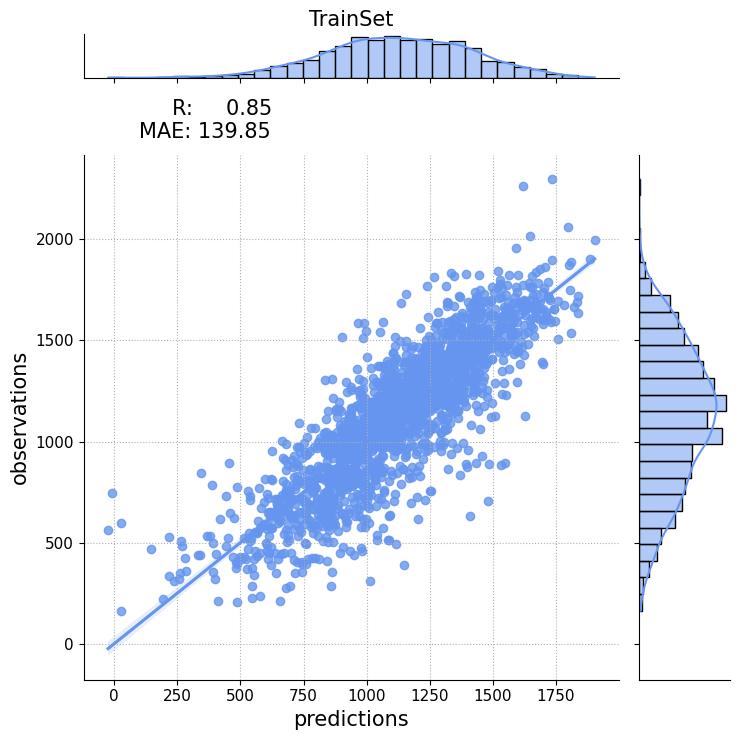

In [ ]:
# Scatter Plot & Marginal Distribution & Correlation Between Observations & Modelled/Predicted Values:
JointPlots(verif.loc[:'2017',:], title='TrainSet', fname='TrainSetJointPlotClimate')

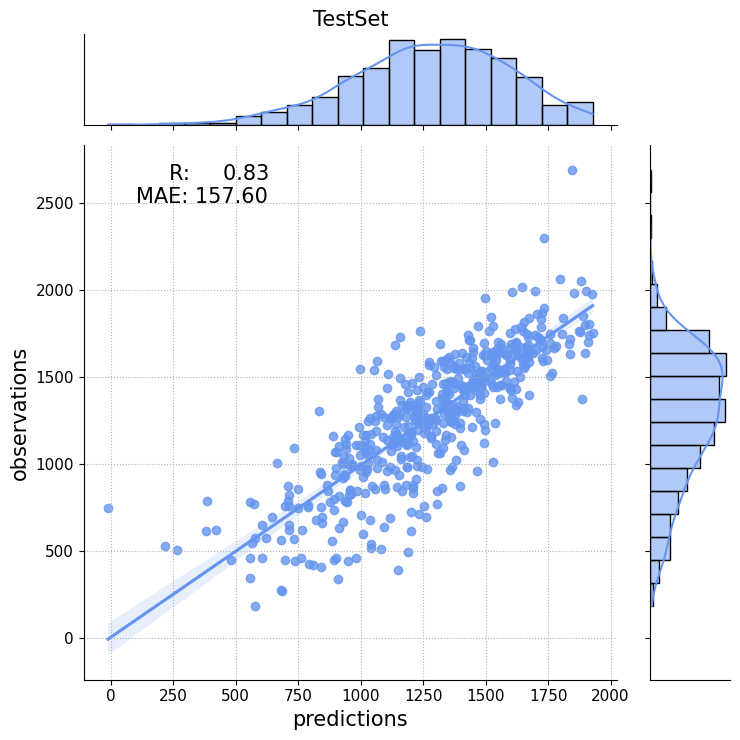

In [ ]:
# Test Set:
JointPlots(verif.loc['2017':,:], title='TestSet', fname='TestSetJointPlotClimate')

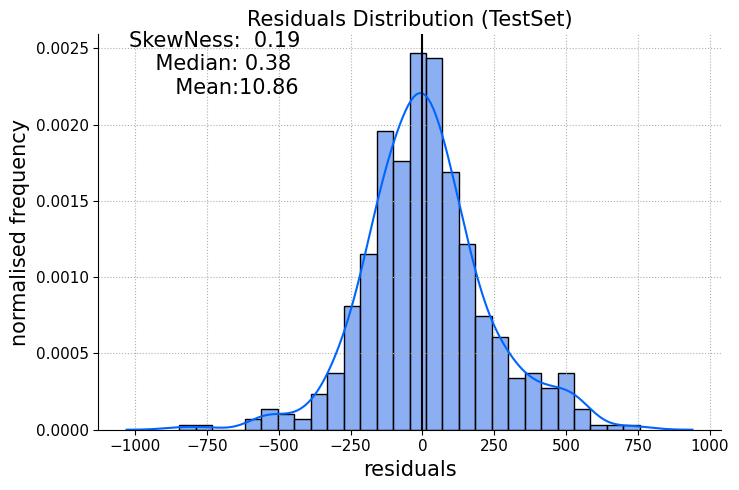

In [ ]:
# Residual Distributions (TestSet):
residuals=verif.loc['2017':,'yhat'] - verif.loc['2017':,'y']
f,ax=plt.subplots(figsize=(7.5,5))
sns.histplot(residuals, ax=ax, color='#6595EE', kde=False, stat='density')
sns.kdeplot( residuals, ax=ax, color='#0065FF')
ax.set_xlabel('residuals'           , fontsize=15)
ax.set_ylabel('normalised frequency', fontsize=15)
ax.grid(ls=':')
[l.set_fontsize(11) for l in ax.xaxis.get_ticklabels()]
[l.set_fontsize(11) for l in ax.yaxis.get_ticklabels()]
ax.text(.05, .85, 'SkewNess:  {:.2f}\n    Median: {:.2f}\n       Mean:{:.2f}'.
        format(skew(residuals), residuals.median(), residuals.mean()),
        fontsize=15, transform=ax.transAxes)
ax.axvline(0, color='.001')
ax.set_title('Residuals Distribution (TestSet)', fontsize=15)
sns.despine(     )
plt.tight_layout()
plt.show(        )
for ext in ['png','jpeg','pdf']: f.savefig(f'/content/ResidualsDistributionTestSetClimate.{ext}', dpi=200)

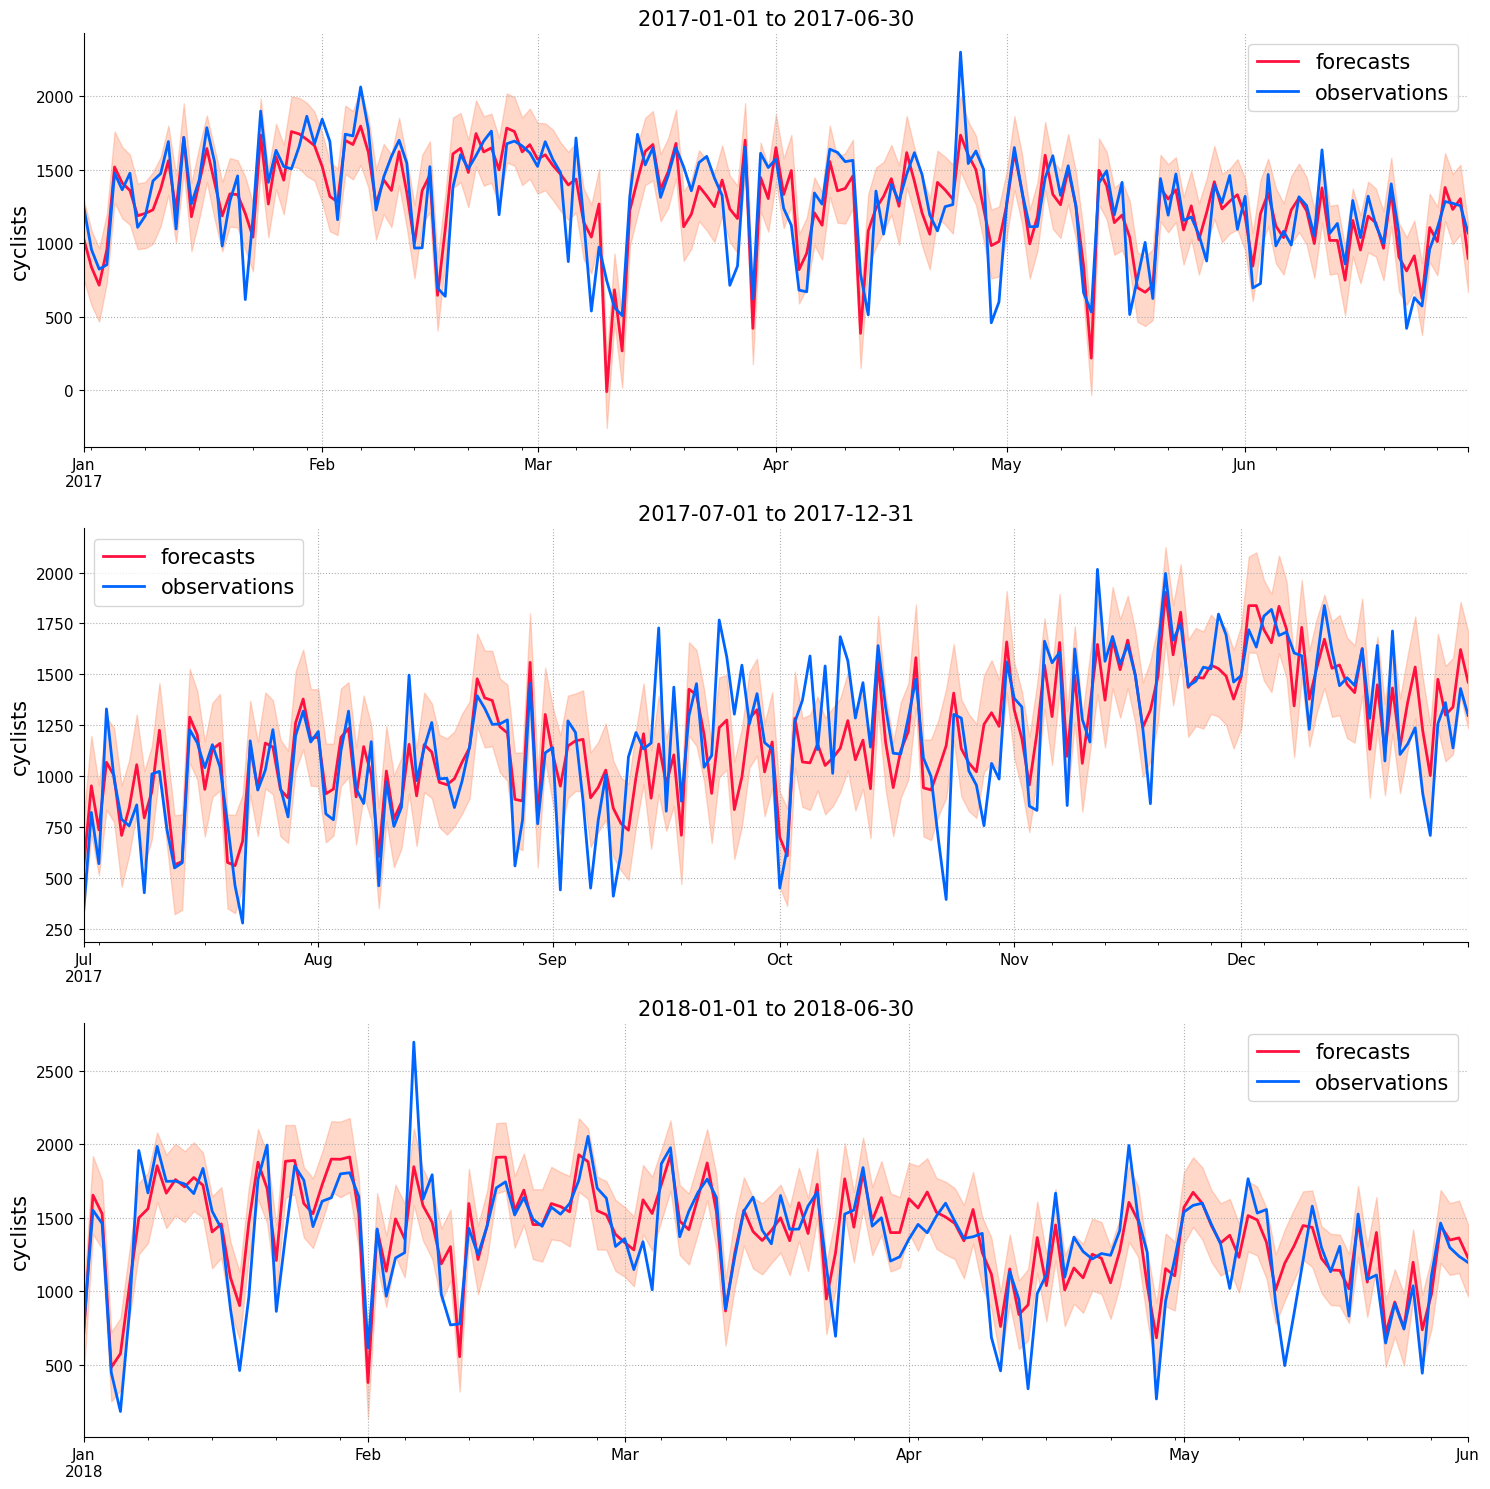

In [ ]:
# Plot ForeCasts & Observed Values in 6 Month Blocks:
def PlotBlock(verif, start, end, ax):
    df=verif.loc[start:end,:]
    df.loc[:,'yhat'].plot(lw=2, ax=ax, color='#FF103F', ls='-', label='forecasts'   )
    ax.fill_between(df.index  , df.loc[:,'yhat_lower'], df.loc[:,'yhat_upper'], color='coral', alpha=.3)
    df.loc[:,'y'   ].plot(lw=2, ax=ax, color='#0065FF', ls='-', label='observations')
    ax.grid(ls=':')
    ax.legend(fontsize=15)
    [l.set_fontsize(11) for l in ax.xaxis.get_ticklabels()]
    [l.set_fontsize(11) for l in ax.yaxis.get_ticklabels()]
    ax.set_ylabel('cyclists'        , fontsize=15)
    ax.set_xlabel('')
    ax.set_title(f'{start} to {end}', fontsize=15)
fig=plt.figure(figsize=(15,15))
ax1=plt.subplot(311)
PlotBlock(verif, '2017-01-01','2017-06-30', ax=ax1)
ax2=plt.subplot(312)
PlotBlock(verif, '2017-07-01','2017-12-31', ax=ax2)
ax3=plt.subplot(313)
PlotBlock(verif, '2018-01-01','2018-06-30', ax=ax3)
ax.set_xlim(    ['2017-01-01','2018-06-30'])
sns.despine(       )
plt.tight_layout(  )
plt.show(          )

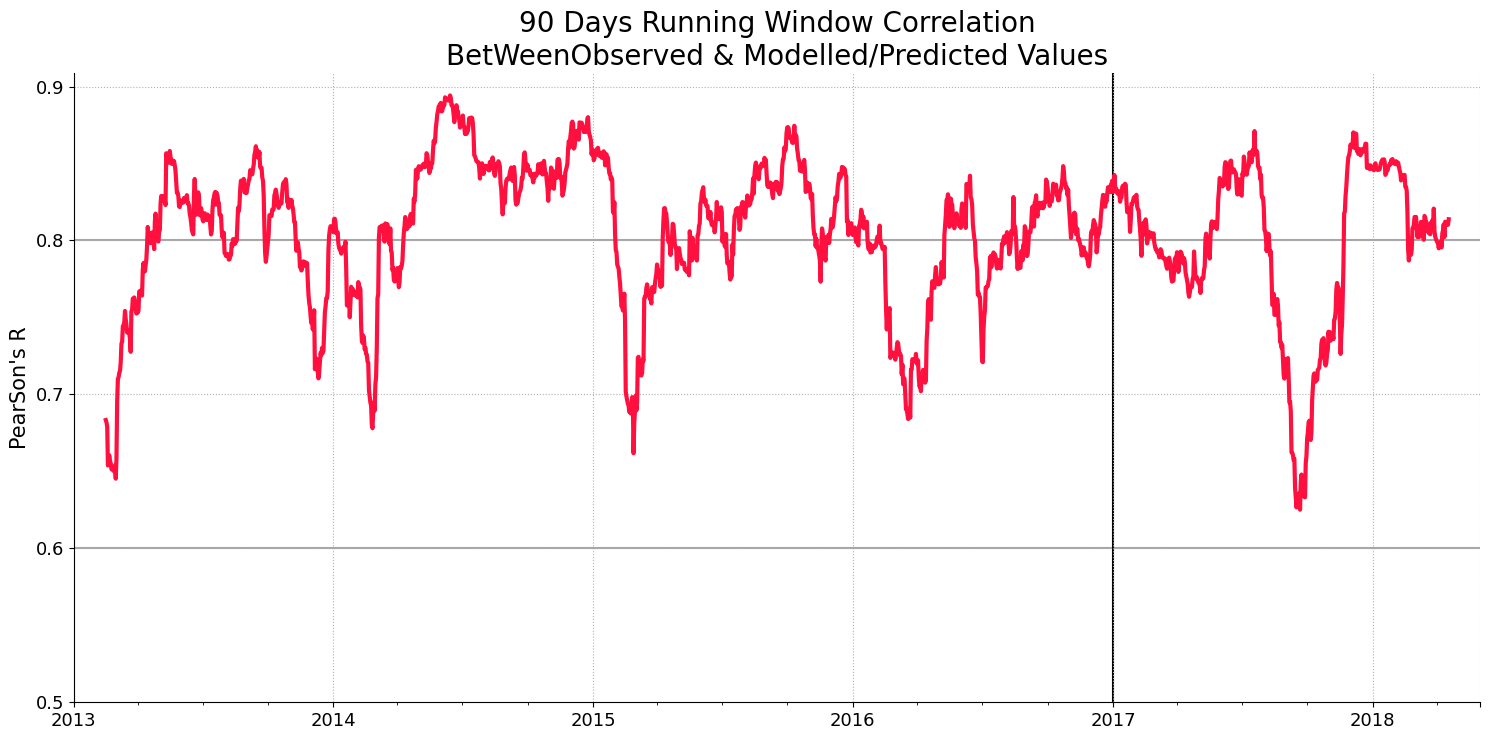

In [ ]:
# Running Correlations (Over 90 Days) Between Observed & Modelled/Predicted Values:
corr=verif.loc[:,['y','yhat']].rolling(window=90, center=True).corr().iloc[0::2,1]
corr.index=corr.index.droplevel(1)
f,ax=plt.subplots(figsize=(15,7.5))
corr.plot(ax=ax, lw=3, color='#FF103F')
ax.axhline(.8        , color='.65', zorder=-1)
ax.axhline(.6        , color='.65', zorder=-1)
ax.axvline('2017'    , color=' 0 ', zorder=-1)
# ax.set_ylim([.5,.9])
ax.set_xlabel('')
ax.set_ylabel("PearSon's R", fontsize=15)
ax.grid(ls=':')
[l.set_fontsize(13) for l in ax.xaxis.get_ticklabels()]
[l.set_fontsize(13) for l in ax.yaxis.get_ticklabels()]
ax.set_yticks(np.arange(.5,1.,.1))
ax.set_title('90 Days Running Window Correlation\nBetWeenObserved & Modelled/Predicted Values', fontsize=20)
sns.despine(     )
plt.tight_layout()
plt.show(        )
for ext in ['png','jpeg','pdf']: f.savefig(f'/content/MovingCorr.{ext}', dpi=200)

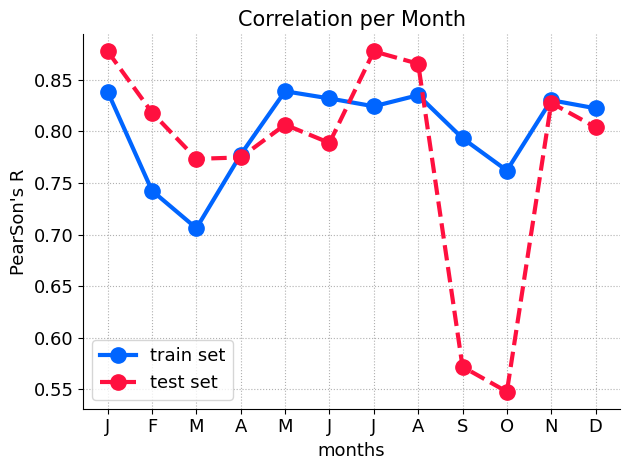

In [ ]:
# Correlation Grouped by Month
# In Search of Seasonality
corrSeasonTest =verif.loc['2017':,['y','yhat']].groupby(verif.loc['2017':,:].index.month).corr()
corrSeasonTrain=verif.loc[:'2017',['y','yhat']].groupby(verif.loc[:'2017',:].index.month).corr()
corrSeason     =verif.loc[:,[      'y','yhat']].groupby(verif.loc[:   ,   :].index.month).corr()
f,ax=plt.subplots()
corrSeasonTrain.xs('y', axis=0, level=1)['yhat'].plot(ax=ax, lw=3, marker='o', markersize=11, label='train set', ls='-' , color='#0065FF')
corrSeasonTest.xs( 'y', axis=0, level=1)['yhat'].plot(ax=ax, lw=3, marker='o', markersize=11, label= 'test set', ls='--', color='#FF103F')
# corrSeason.xs('y', axis=0, level=1)['yhat'].plot(ax=ax, lw=3, marker='o', markersize=11)
ax.legend(fontsize=13, loc=3)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(list('JFMAMJJASOND'))
ax.set_xlabel('months'     , fontsize=13)
ax.set_ylabel("PearSon's R", fontsize=13)
ax.grid(ls=':')
[l.set_fontsize(13) for l in ax.xaxis.get_ticklabels()]
[l.set_fontsize(13) for l in ax.yaxis.get_ticklabels()]
ax.set_title('Correlation per Month', fontsize=15)
sns.despine(     )
plt.tight_layout()
plt.show(        )
for ext in ['png','jpeg','pdf']: f.savefig(f'/content/CorrelationObsPredPerMonth.{ext}', dpi=200)

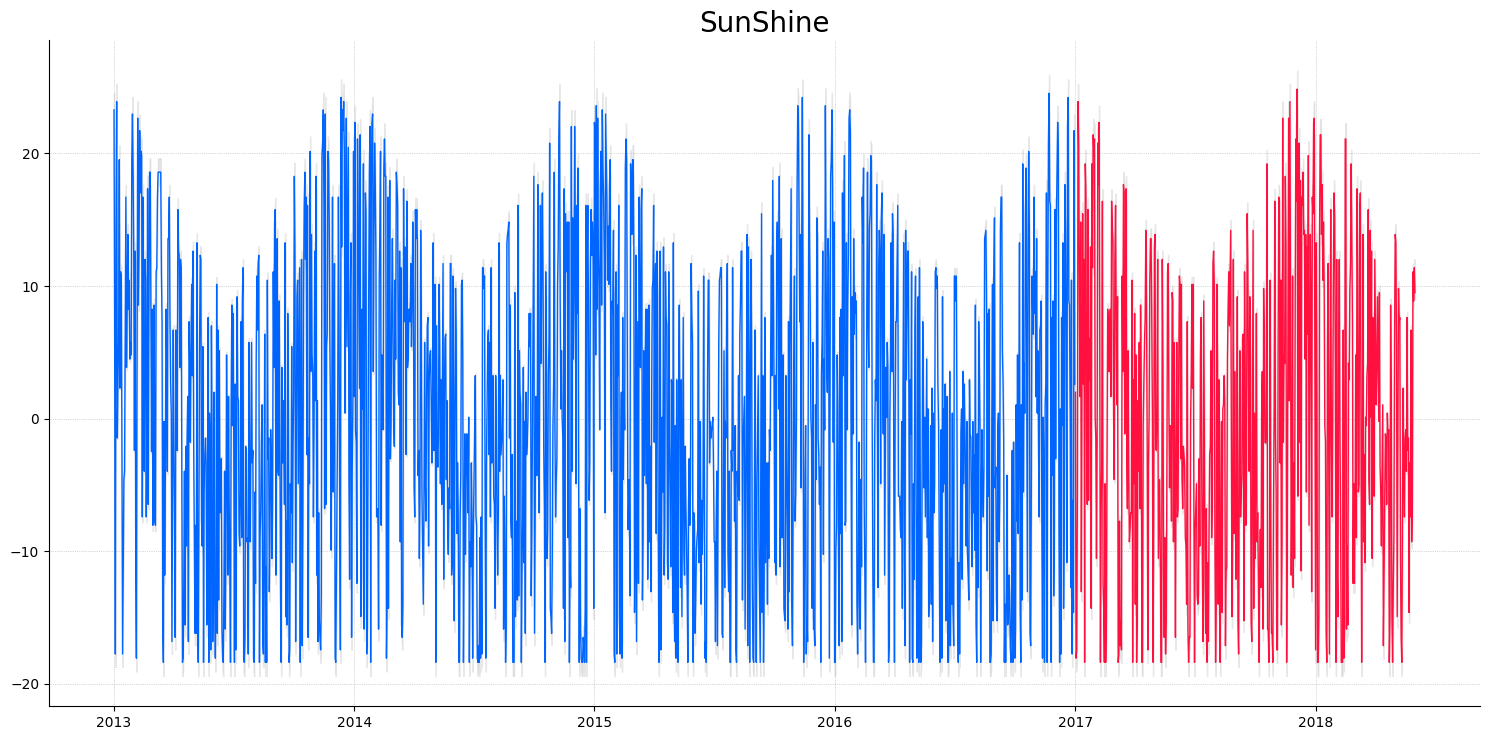

In [ ]:
# Plotting Contribution of Different Climate Variables to Response Variable
#(in percentage of trend component, as multiplicative model was chosen)
def PlotVerifComponent(verif, component, year):
    '''
    plots a specific component of the `verif` DataFrame
    Parameters:
    ----------
    verif    : pandas.DataFrame –`verif` DataFrame coming from the `make_verif` function.
    component: string           – name of the component (i.e. column name) to plot in the `verif` DataFrame.
    year     : integer          – year used to separate the training and test set.
    Returns:
    -------
    f : matplotlib Figure object
    '''
    f,ax =plt.subplots(figsize=(15,7.5))
    train=verif.loc[:str(year - 1),  :]
    ax.plot(train.index, train.loc[:,component] * 100, color='#0065FF', lw=1, ls='-')
    ax.fill_between(train.index, train.loc[:, component+'_lower'] * 100, train.loc[:, component+'_upper'] * 100, color='.75', alpha=.35)
    test =verif.loc[str(year):,:]
    ax.plot( test.index,  test.loc[:,component] * 100, color='#FF103F', lw=1, ls='-')
    ax.fill_between( test.index,  test.loc[:, component+'_lower'] * 100,  test.loc[:, component+'_upper'] * 100, color='.75', alpha=.35)
   #ax.axvline(     str(year)  ,                       color=' 0 ',                                                           alpha=.75)
    ax.grid(ls=':', lw=.5)
    return f
# Sun
f=PlotVerifComponent(verif,'sun',2017)
sns.despine(        )
plt.title('SunShine', fontsize=20)
plt.tight_layout(   )
plt.show(           )

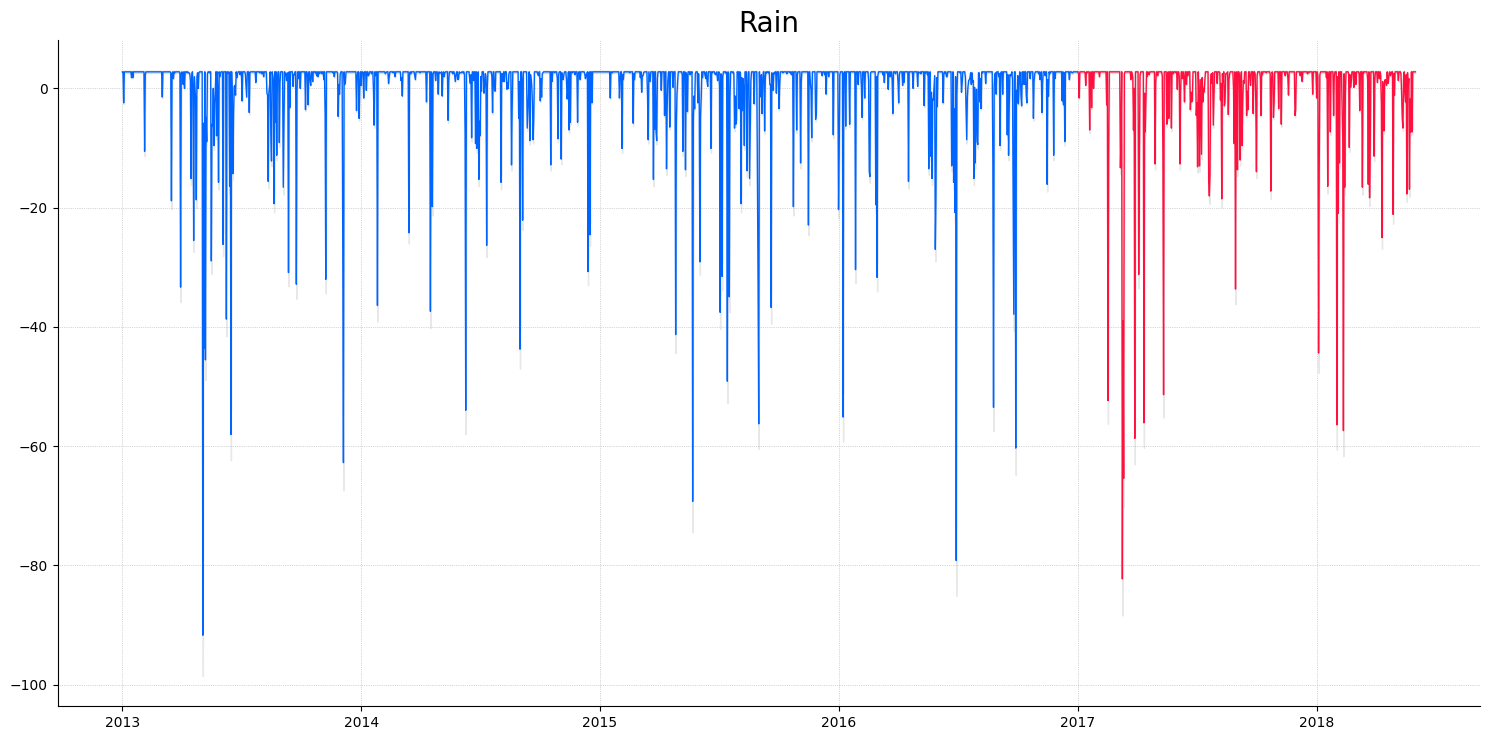

In [ ]:
# Rain
f=PlotVerifComponent(verif,'rain',2017)
sns.despine(        )
plt.title('Rain'    , fontsize=20)
plt.tight_layout(   )
plt.show(           )

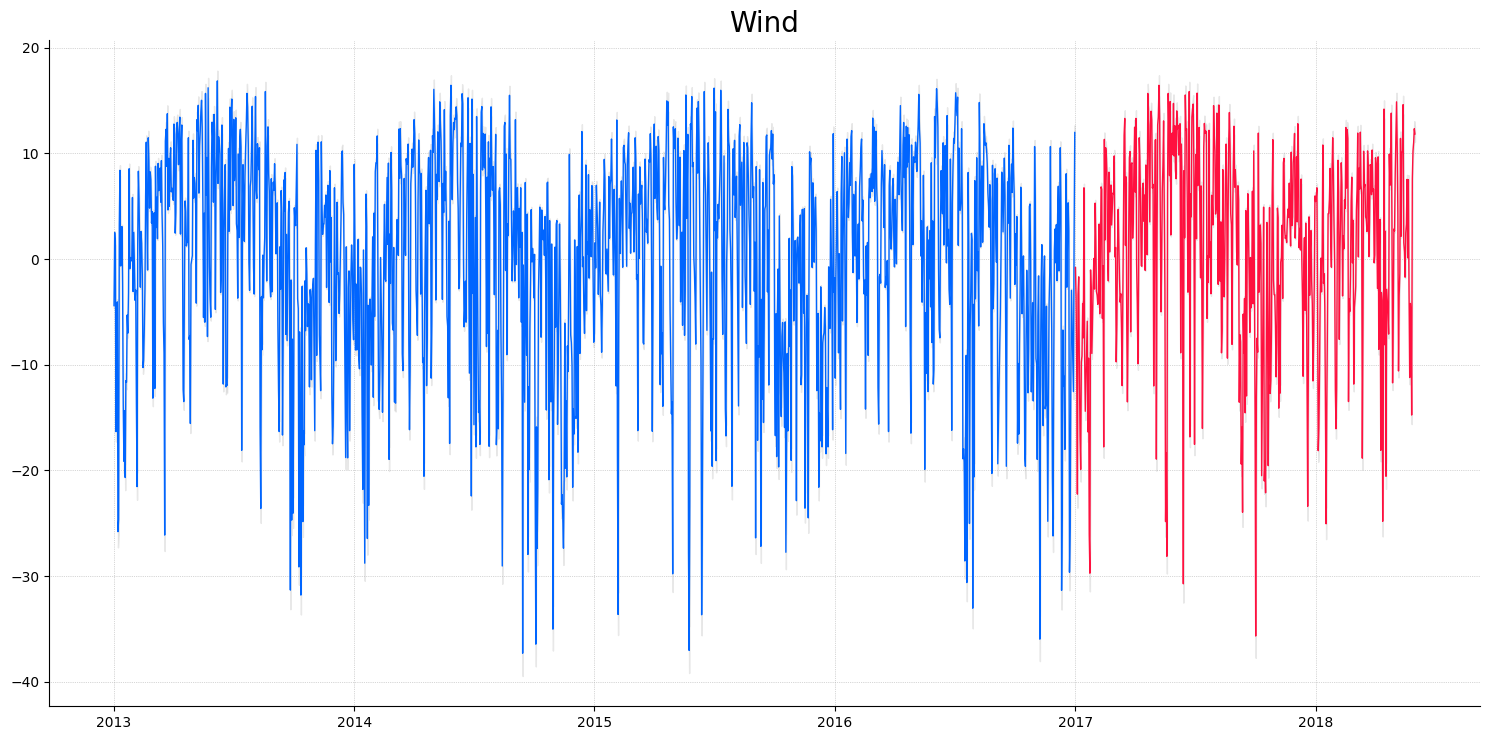

In [ ]:
# Wind
f=PlotVerifComponent(verif,'wind',2017)
sns.despine(        )
plt.title('Wind'    , fontsize=20)
plt.tight_layout(   )
plt.show(           )

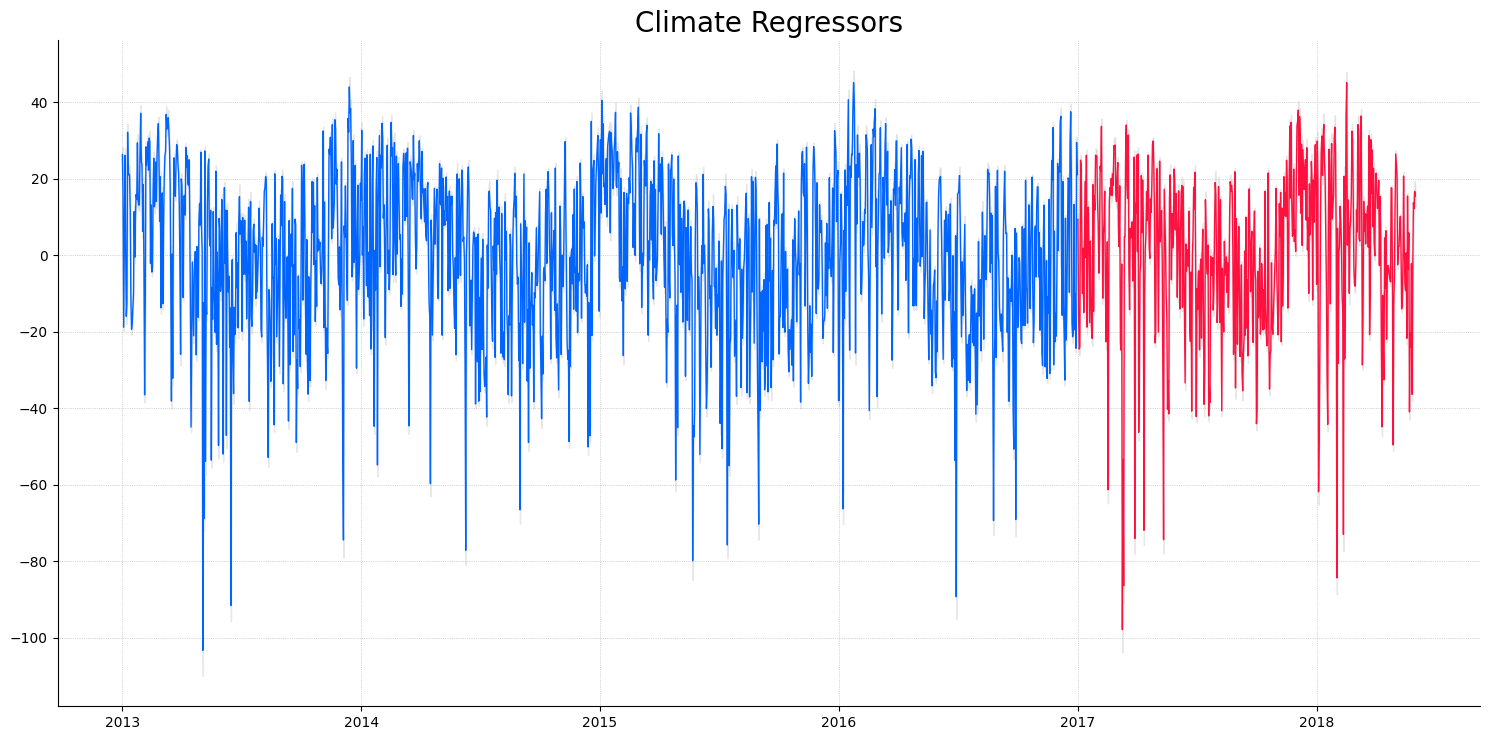

In [ ]:
# Combined Contribution of Climate Extra Regressors:
f=PlotVerifComponent(verif,'extra_regressors_multiplicative',2017)
sns.despine(        )
plt.title('Climate Regressors', fontsize=20)
plt.tight_layout(   )
plt.show(           )